# IRBF

The purpose of this notebook is to test the main notebook with a limit of 300 GHz without secondary rescattering to understand the impact of our secondary-scattering correction.

## Imports, Definitions, and loading data

In [33]:
## Critical Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patheffects as PathEffects
import cmasher as cmr

import scipy.constants as const
# from scipy.optimize import curve_fit
import pandas as pd
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from scipy.signal import find_peaks
from itertools import cycle

# Nested Sampling
import dynesty
import corner
import pickle
import os

#Aesthetics
import matplotlib as mpl
plt.style.use('style.mplstyle')

# My stuff
from TeraToptica import TeraFlashAnalyzer as TFA, TeraFlashConfig as TFC
from TeraToptica import TeraScanAnalyzer as TSA, TeraScanConfig as TSC

window = 'gaussian' # Smoothing window type in frequency domain
window_size  = 15 # Determines how many GHz to smooth the spectrum over (upper bound)

mask_bounds = ((0, 150), (300, 10000))

f = np.arange(5, 350.1, 1)

batches = {}

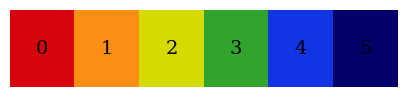

In [34]:
from cmap import Colormap
cmap = Colormap('colorcet:CET_R4')
# cmap = cmr.horizon
# cmap = Colormap('magma')


cmap_array = cmap(np.linspace(0, 1, 256))[::-1]

entries = 6
indices = np.linspace(0, len(cmap_array)-1, entries).astype(int)
colors2 = cmap_array[indices]

# Display for visualization
large_font = 14  # font size for labels
plt.figure(figsize=(5, 1))
plt.imshow([colors2], aspect='auto')

for i in range(len(colors2)):  # one less because we skipped first color
    plt.annotate(i, (i, 0), color='k', fontsize=large_font, ha='center', va='center')

plt.gca().set_axis_off()

# =========================
# Colormap infrastructure
# =========================

# HD30 default colormaps (Batch1, Batch2, Batch3)
def apply_cmap(bname, cmap, lo=0.4, hi=0.85, mean_pos=0.6):
    sample_dict = batches[bname]

    keys = list(sample_dict.keys())
    cols = cmap(np.linspace(lo, hi, len(keys)))
    cols = cols[::-1]

    for s, c in zip(keys, cols):
        sample_dict[s]["color"] = c

    comb_batches[bname]["color"] = cmap(mean_pos)

In [35]:
from matplotlib.colors import to_rgb
import colorsys

# Linearly steps through value, works best with high saturation colors
def get_colors(N, stop_color, start_v=1, stop_v=0.5):
    r, g, b = to_rgb(stop_color)
    h, s, _ = colorsys.rgb_to_hsv(r, g, b)

    v_values = np.linspace(start_v, stop_v, N)
    colors = [colorsys.hsv_to_rgb(h, s, v) for v in v_values]
    return np.array(colors)

### Styrofoam

In [36]:
tf_cfg = TFC(
    window=window,
    window_size=window_size,
    mask_bounds=mask_bounds,
    layout='reference_included'
)

tf_cfg2 = TFC(
    window=window,
    window_size=window_size,
    mask_bounds=mask_bounds,
    layout='separate_files'
)

#These were NOT cycled in a vacuum chamber

path = './data/20260605/' #Check the repeatability of the thin styrofoams

styro_0o8mm  = TFA(path, 'styro_thin1_0o8mm_1850-2050ps_100avgs', config=tf_cfg)
styro_1o5mm  = TFA(path, 'styro_thin2_1o5mm_1850-2050ps_100avgs', config=tf_cfg)

styro_6o1mm  = TFA(path, 'styro_6o1mm_1850-2050ps_100avgs',  config=tf_cfg)

styro_13o5mm = TFA(path, 'styro_13o5mm_1850-2050ps_100avgs', config=tf_cfg)
styro_42o3mm = TFA(path, 'styro_filter_1850-2050ps_100avgs', config=tf_cfg)

# Data beyond this point was deployed for initial SATp2 observations
path = './data/20260518/'

SATp2_site_sample4_1_45o3mm = TFA(path, 'satp2_site_sample4_1_45o3mm_2210-2410ps_100avgs', 'open_2210-2410ps_100avgs', config=tf_cfg2)

path = './data/20260529/'
base = 'open2_1850-2050ps_100avgs'

sample4_thick_5o8mm = TFA(path, 'SATp2_site_sample4_5o8mm_2_1850-2050ps_100avgs', base, config=tf_cfg2)
sample4_thin_16o2mm = TFA(path, 'SATp2_site_sample4_16o2mm_2_1850-2050ps_100avgs', base, config=tf_cfg2)
sample4_thin_16o9mm = TFA(path, 'SATp2_site_sample4_16o9mm_1850-2050ps_100avgs', base, config=tf_cfg2)
sample4_thick_5o6mm = TFA(path, 'SATp2_site_sample4_5o6mm_1850-2050ps_100avgs', base, config=tf_cfg2)

## Frequency domain data for Styrofoam
f_0o8mm,  t_0o8mm,  ut_0o8mm,  mask_0o8mm,  err_0o8mm,  boxnum_0o8mm  = styro_0o8mm.get_smoothed_spectra()
f_1o5mm,  t_1o5mm,  ut_1o5mm,  mask_1o5mm,  err_1o5mm,  boxnum_1o5mm  = styro_1o5mm.get_smoothed_spectra()
f_6o1mm,  t_6o1mm,  ut_6o1mm,  mask_6o1mm,  err_6o1mm,  boxnum_6o1mm  = styro_6o1mm.get_smoothed_spectra()
f_13o5mm, t_13o5mm, ut_13o5mm, mask_13o5mm, err_13o5mm, boxnum_13o5mm = styro_13o5mm.get_smoothed_spectra()
f_42o3mm, t_42o3mm, ut_42o3mm, mask_42o3mm, err_42o3mm, boxnum_42o3mm = styro_42o3mm.get_smoothed_spectra()
f_45o3mm, t_45o3mm, ut_45o3mm, mask_45o3mm, err_45o3mm, boxnum_45o3mm = SATp2_site_sample4_1_45o3mm.get_smoothed_spectra()
f_5o8mm,  t_5o8mm,  ut_5o8mm,  mask_5o8mm,  err_5o8mm,  boxnum_5o8mm  = sample4_thick_5o8mm.get_smoothed_spectra()
f_16o2mm, t_16o2mm, ut_16o2mm, mask_16o2mm, err_16o2mm, boxnum_16o2mm = sample4_thin_16o2mm.get_smoothed_spectra()
f_16o9mm, t_16o9mm, ut_16o9mm, mask_16o9mm, err_16o9mm, boxnum_16o9mm = sample4_thin_16o9mm.get_smoothed_spectra()
f_5o6mm,  t_5o6mm,  ut_5o6mm,  mask_5o6mm,  err_5o6mm,  boxnum_5o6mm  = sample4_thick_5o6mm.get_smoothed_spectra()


## Time domain data for Styrofoam
T_0o8mm,  pc_0o8mm  = styro_0o8mm.get_sample_pulse()
T_1o5mm,  pc_1o5mm  = styro_1o5mm.get_sample_pulse()
T_6o1mm,  pc_6o1mm  = styro_6o1mm.get_sample_pulse()
T_13o5mm, pc_13o5mm = styro_13o5mm.get_sample_pulse()
T_42o3mm, pc_42o3mm = styro_42o3mm.get_sample_pulse()
T_45o3mm, pc_45o3mm = SATp2_site_sample4_1_45o3mm.get_sample_pulse()
T_5o8mm,  pc_5o8mm  = sample4_thick_5o8mm.get_sample_pulse()
T_16o2mm, pc_16o2mm = sample4_thin_16o2mm.get_sample_pulse()
T_16o9mm, pc_16o9mm = sample4_thin_16o9mm.get_sample_pulse()
T_5o6mm,  pc_5o6mm  = sample4_thick_5o6mm.get_sample_pulse()

# Phase data for Styrofoam
theta_0o8mm,  theta_base_0o8mm  = styro_0o8mm.get_phases()
theta_1o5mm,  theta_base_1o5mm  = styro_1o5mm.get_phases()
theta_6o1mm,  theta_base_6o1mm  = styro_6o1mm.get_phases()
theta_13o5mm, theta_base_13o5mm = styro_13o5mm.get_phases()
theta_42o3mm, theta_base_42o3mm = styro_42o3mm.get_phases()
theta_45o3mm, theta_base_45o3mm = SATp2_site_sample4_1_45o3mm.get_phases()
theta_5o8mm,  theta_base_5o8mm  = sample4_thick_5o8mm.get_phases()
theta_16o2mm, theta_base_16o2mm = sample4_thin_16o2mm.get_phases()
theta_16o9mm, theta_base_16o9mm = sample4_thin_16o9mm.get_phases()
theta_5o6mm,  theta_base_5o6mm  = sample4_thick_5o6mm.get_phases()

Styrofoam_batch = {}

Styrofoam_batch["Styrofoam 0.08 cm"] = {'f': f_0o8mm,  't': t_0o8mm,  'ut': ut_0o8mm,  'mask': mask_0o8mm,  'err': err_0o8mm,  'boxnum': boxnum_0o8mm,  'T': T_0o8mm,  'pc': pc_0o8mm,  'theta': theta_0o8mm,  'theta_base': theta_base_0o8mm,  'width': 0.08}
Styrofoam_batch["Styrofoam 0.15 cm"] = {'f': f_1o5mm,  't': t_1o5mm,  'ut': ut_1o5mm,  'mask': mask_1o5mm,  'err': err_1o5mm,  'boxnum': boxnum_1o5mm,  'T': T_1o5mm,  'pc': pc_1o5mm,  'theta': theta_1o5mm,  'theta_base': theta_base_1o5mm,  'width': 0.15}
Styrofoam_batch["Styrofoam 0.61 cm"] = {'f': f_6o1mm,  't': t_6o1mm,  'ut': ut_6o1mm,  'mask': mask_6o1mm,  'err': err_6o1mm,  'boxnum': boxnum_6o1mm,  'T': T_6o1mm,  'pc': pc_6o1mm,  'theta': theta_6o1mm,  'theta_base': theta_base_6o1mm,  'width': 0.61}
Styrofoam_batch["Styrofoam 1.35 cm"] = {'f': f_13o5mm, 't': t_13o5mm, 'ut': ut_13o5mm, 'mask': mask_13o5mm, 'err': err_13o5mm, 'boxnum': boxnum_13o5mm, 'T': T_13o5mm, 'pc': pc_13o5mm, 'theta': theta_13o5mm, 'theta_base': theta_base_13o5mm, 'width': 1.35}
Styrofoam_batch["Styrofoam 4.23 cm"] = {'f': f_42o3mm, 't': t_42o3mm, 'ut': ut_42o3mm, 'mask': mask_42o3mm, 'err': err_42o3mm, 'boxnum': boxnum_42o3mm, 'T': T_42o3mm, 'pc': pc_42o3mm, 'theta': theta_42o3mm, 'theta_base': theta_base_42o3mm, 'width': 4.23}
Styrofoam_batch['Styrofoam 0.56 cm'] = {'f': f_5o6mm,  't': t_5o6mm,  'ut': ut_5o6mm,  'mask': mask_5o6mm,  'err': err_5o6mm,  'boxnum': boxnum_5o6mm,  'T': T_5o6mm,  'pc': pc_5o6mm,  'theta': theta_5o6mm,  'theta_base': theta_base_5o6mm,  'width': 0.56}
Styrofoam_batch['Styrofoam 0.58 cm'] = {'f': f_5o8mm,  't': t_5o8mm,  'ut': ut_5o8mm,  'mask': mask_5o8mm,  'err': err_5o8mm,  'boxnum': boxnum_5o8mm,  'T': T_5o8mm,  'pc': pc_5o8mm,  'theta': theta_5o8mm,  'theta_base': theta_base_5o8mm,  'width': 0.58}
Styrofoam_batch['Styrofoam 1.62 cm'] = {'f': f_16o2mm, 't': t_16o2mm, 'ut': ut_16o2mm, 'mask': mask_16o2mm, 'err': err_16o2mm, 'boxnum': boxnum_16o2mm, 'T': T_16o2mm, 'pc': pc_16o2mm, 'theta': theta_16o2mm, 'theta_base': theta_base_16o2mm, 'width': 1.62}
Styrofoam_batch['Styrofoam 1.69 cm'] = {'f': f_16o9mm, 't': t_16o9mm, 'ut': ut_16o9mm, 'mask': mask_16o9mm, 'err': err_16o9mm, 'boxnum': boxnum_16o9mm, 'T': T_16o9mm, 'pc': pc_16o9mm, 'theta': theta_16o9mm, 'theta_base': theta_base_16o9mm, 'width': 1.69}
Styrofoam_batch['Styrofoam 4.53 cm'] = {'f': f_45o3mm, 't': t_45o3mm, 'ut': ut_45o3mm, 'mask': mask_45o3mm, 'err': err_45o3mm, 'boxnum': boxnum_45o3mm, 'T': T_45o3mm, 'pc': pc_45o3mm, 'theta': theta_45o3mm, 'theta_base': theta_base_45o3mm, 'width': 4.53}

batches['Styrofoam_batch'] = Styrofoam_batch

### HD30_batch1

In [37]:
# TeraFlashAnalyzer Instances for HD30_batch1
path = './data/20251216/'
penn_3o47mm    = TFA(path, 'HD30_1x0o125in_3o47mm_penn_1675-1875ps_100avgs', config=tf_cfg)

path = './data/20260212'
penn_6o51mm  = TFA(path, 'hd30_penn_6o51mm_1400-1600ps_100avgs', config=tf_cfg) # 2x1/8"
penn_27o6mm  = TFA(path, 'hd30_penn_27o60mm_1400-1600ps_100avgs', config=tf_cfg) # 8x1/8"
penn_30o94mm = TFA(path, 'hd30_penn_30o94mm_1400-1600ps_100avgs', config=tf_cfg) # 10x1/8

# Frequency domain data for HD30_batch1
f_3o47mm,  t_3o47mm,  ut_3o47mm,  mask_3o47mm,  err_3o47mm,  boxnum_3o47mm  = penn_3o47mm.get_smoothed_spectra()
f_6o51mm,  t_6o51mm,  ut_6o51mm,  mask_6o51mm,  err_6o51mm,  boxnum_6o51mm  = penn_6o51mm.get_smoothed_spectra()
f_27o6mm,  t_27o6mm,  ut_27o6mm,  mask_27o6mm,  err_27o6mm,  boxnum_27o6mm  = penn_27o6mm.get_smoothed_spectra()
f_30o94mm, t_30o94mm, ut_30o94mm, mask_30o94mm, err_30o94mm, boxnum_30o94mm = penn_30o94mm.get_smoothed_spectra()

# Time domain data for HD30_batch1
T_3o47mm,  pc_3o47mm  = penn_3o47mm.get_sample_pulse()
T_6o51mm,  pc_6o51mm  = penn_6o51mm.get_sample_pulse()
T_27o6mm,  pc_27o6mm  = penn_27o6mm.get_sample_pulse()
T_30o94mm, pc_30o94mm = penn_30o94mm.get_sample_pulse()

# Phase data for HD30_batch1
theta_3o47mm,  theta_base_3o47mm  = penn_3o47mm.get_phases()
theta_6o51mm,  theta_base_6o51mm  = penn_6o51mm.get_phases()
theta_27o6mm,  theta_base_27o6mm  = penn_27o6mm.get_phases()
theta_30o94mm, theta_base_30o94mm = penn_30o94mm.get_phases()

HD30_batch1 = {}
HD30_batch1['HD30 batch1 0.35 cm'] = {'f': f_3o47mm,  't': t_3o47mm,  'ut': ut_3o47mm,  'mask': mask_3o47mm,  'err': err_3o47mm,  'boxnum': boxnum_3o47mm,  'T': T_3o47mm,  'pc': pc_3o47mm,  'theta_base': theta_base_3o47mm,  'theta': theta_3o47mm,  'width': 0.347}
HD30_batch1['HD30 batch1 0.65 cm'] = {'f': f_6o51mm,  't': t_6o51mm,  'ut': ut_6o51mm,  'mask': mask_6o51mm,  'err': err_6o51mm,  'boxnum': boxnum_6o51mm,  'T': T_6o51mm,  'pc': pc_6o51mm,  'theta_base': theta_base_6o51mm,  'theta': theta_6o51mm,  'width': 0.651}
HD30_batch1['HD30 batch1 2.76 cm'] = {'f': f_27o6mm,  't': t_27o6mm,  'ut': ut_27o6mm,  'mask': mask_27o6mm,  'err': err_27o6mm,  'boxnum': boxnum_27o6mm,  'T': T_27o6mm,  'pc': pc_27o6mm,  'theta_base': theta_base_27o6mm,  'theta': theta_27o6mm,  'width': 2.76}
HD30_batch1['HD30 batch1 3.09 cm'] = {'f': f_30o94mm, 't': t_30o94mm, 'ut': ut_30o94mm, 'mask': mask_30o94mm, 'err': err_30o94mm, 'boxnum': boxnum_30o94mm, 'T': T_30o94mm, 'pc': pc_30o94mm, 'theta_base': theta_base_30o94mm, 'theta': theta_30o94mm, 'width': 3.094}

batches['HD30_batch1'] = HD30_batch1

### HD30_batch2

In [38]:
path = './data/20251216/'

## TeraFlashAnalyzer Instances for HD30_batch2
cornell_3o65mm = TFA(path, 'hd30_1x0o125in_3o65mm_cornell_1675-1875ps_100avgs', config = tf_cfg)
cornell_7o3mm  = TFA(path, 'hd30_2x0o125in_7o3mm_cornell_1675-1875ps_100avgs',  config = tf_cfg)
cornell_25o4mm = TFA(path, 'hd30_1x1in_25o4mm_cornell2_1675-1875ps_100avgs',    config = tf_cfg)

## Frequency domain data for HD30_batch2
f_3o65mm, t_3o65mm,  ut_3o65mm,  mask_3o65mm,  err_3o65mm,  boxnum_3o65mm  = cornell_3o65mm.get_smoothed_spectra()
f_7o3mm,  t_7o3mm,   ut_7o3mm,   mask_7o3mm,   err_7o3mm,   boxnum_7o3mm   = cornell_7o3mm.get_smoothed_spectra()
f_25o4mm, t_25o4mm,  ut_25o4mm,  mask_25o4mm,  err_25o4mm,  boxnum_25o4mm  = cornell_25o4mm.get_smoothed_spectra()

## Time domain data for HD30_batch2
T_3o65mm,  pc_3o65mm  = cornell_3o65mm.get_sample_pulse()
T_7o3mm,   pc_7o3mm   = cornell_7o3mm.get_sample_pulse()
T_25o4mm,  pc_25o4mm  = cornell_25o4mm.get_sample_pulse()

## Phase data for HD30_batch2
theta_3o65mm, theta_base_3o65mm = cornell_3o65mm.get_phases()
theta_7o3mm,  theta_base_7o3mm  = cornell_7o3mm.get_phases()
theta_25o4mm, theta_base_25o4mm = cornell_25o4mm.get_phases()

HD30_batch2 = {}

HD30_batch2['HD30 batch2 0.37 cm'] = {'f': f_3o65mm, 't': t_3o65mm, 'ut': ut_3o65mm, 'mask': mask_3o65mm, 'err': err_3o65mm, 'boxnum': boxnum_3o65mm, 'T': T_3o65mm, 'pc': pc_3o65mm, 'theta_base': theta_base_3o65mm, 'theta': theta_3o65mm, 'width': 0.365}
HD30_batch2['HD30 batch2 0.73 cm'] = {'f': f_7o3mm,  't': t_7o3mm,  'ut': ut_7o3mm,  'mask': mask_7o3mm,  'err': err_7o3mm,  'boxnum': boxnum_7o3mm,  'T': T_7o3mm,  'pc': pc_7o3mm,  'theta_base': theta_base_7o3mm,  'theta': theta_7o3mm,  'width': 0.73}
HD30_batch2['HD30 batch2 2.54 cm'] = {'f': f_25o4mm, 't': t_25o4mm, 'ut': ut_25o4mm, 'mask': mask_25o4mm, 'err': err_25o4mm, 'boxnum': boxnum_25o4mm, 'T': T_25o4mm, 'pc': pc_25o4mm, 'theta_base': theta_base_25o4mm, 'theta': theta_25o4mm, 'width': 2.54}

batches['HD30_batch2'] = HD30_batch2

### HD30_batch3
Deployed for ASO

In [39]:
path = './data/20251216/'

site_3o58mm    = TFA(path, 'HD30_1x0o125in_3o58mm_site_1675-1875ps_100avgs',  config=tf_cfg)
site_7o18mm    = TFA(path, 'HD30_2x0o125in_7o18mm_site_1675-1875ps_100avgs',  config=tf_cfg)
site_10o86mm   = TFA(path, 'HD30_3x0o125in_10o86mm_site_1675-1875ps_100avgs', config=tf_cfg)
site_25o4mm    = TFA(path, 'HD30_1x1in_25o4mm_site_1675-1875ps_100avgs',      config=tf_cfg)
site_50o9mm    = TFA(path, 'HD30_2x1in_50o9mm_site_1675-1875ps_100avgs',      config=tf_cfg)

## Frequency domain data for HD30_batch3 
f_3o58mm,  t_3o58mm,  ut_3o58mm,  mask_3o58mm,  err_3o58mm,  boxnum_3o58mm  = site_3o58mm.get_smoothed_spectra()
f_7o18mm,  t_7o18mm,  ut_7o18mm,  mask_7o18mm,  err_7o18mm,  boxnum_7o18mm  = site_7o18mm.get_smoothed_spectra()
f_10o86mm, t_10o86mm, ut_10o86mm, mask_10o86mm, err_10o86mm, boxnum_10o86mm = site_10o86mm.get_smoothed_spectra()
f_25o4mm,  t_25o4mm,  ut_25o4mm,  mask_25o4mm,  err_25o4mm,  boxnum_25o4mm  = site_25o4mm.get_smoothed_spectra()
f_50o9mm,  t_50o9mm,  ut_50o9mm,  mask_50o9mm,  err_50o9mm,  boxnum_50o9mm  = site_50o9mm.get_smoothed_spectra()

## Time domain data for HD30_batch3 
T_3o58mm,  pc_3o58mm  = site_3o58mm.get_sample_pulse()
T_7o18mm,  pc_7o18mm  = site_7o18mm.get_sample_pulse()
T_10o86mm, pc_10o86mm = site_10o86mm.get_sample_pulse()
T_25o4mm,  pc_25o4mm  = site_25o4mm.get_sample_pulse()
T_50o9mm,  pc_50o9mm  = site_50o9mm.get_sample_pulse()

# Phase HD30_batch3
theta_3o58mm, theta_base_3o58mm   = site_3o58mm.get_phases()
theta_7o18mm, theta_base_7o18mm   = site_7o18mm.get_phases()
theta_10o86mm, theta_base_10o86mm = site_10o86mm.get_phases()
theta_25o4mm, theta_base_25o4mm   = site_25o4mm.get_phases()
theta_50o9mm, theta_base_50o9mm   = site_50o9mm.get_phases()

HD30_batch3 = {}

HD30_batch3['HD30 batch3 0.36 cm'] = {'f': f_3o58mm,  't': t_3o58mm,  'ut': ut_3o58mm,  'mask': mask_3o58mm,  'err': err_3o58mm,  'boxnum': boxnum_3o58mm,  'T': T_3o58mm,  'pc': pc_3o58mm,  'theta': theta_3o58mm,  'theta_base': theta_base_3o58mm,  'width': 0.358}
HD30_batch3['HD30 batch3 0.72 cm'] = {'f': f_7o18mm,  't': t_7o18mm,  'ut': ut_7o18mm,  'mask': mask_7o18mm,  'err': err_7o18mm,  'boxnum': boxnum_7o18mm,  'T': T_7o18mm,  'pc': pc_7o18mm,  'theta': theta_7o18mm,  'theta_base': theta_base_7o18mm,  'width': 0.718}
HD30_batch3['HD30 batch3 1.09 cm'] = {'f': f_10o86mm, 't': t_10o86mm, 'ut': ut_10o86mm, 'mask': mask_10o86mm, 'err': err_10o86mm, 'boxnum': boxnum_10o86mm, 'T': T_10o86mm, 'pc': pc_10o86mm, 'theta': theta_10o86mm, 'theta_base': theta_base_10o86mm, 'width': 1.086}
HD30_batch3['HD30 batch3 2.54 cm'] = {'f': f_25o4mm,  't': t_25o4mm,  'ut': ut_25o4mm,  'mask': mask_25o4mm,  'err': err_25o4mm,  'boxnum': boxnum_25o4mm,  'T': T_25o4mm,  'pc': pc_25o4mm,  'theta': theta_25o4mm,  'theta_base': theta_base_25o4mm,  'width': 2.54}
HD30_batch3['HD30 batch3 5.09 cm'] = {'f': f_50o9mm,  't': t_50o9mm,  'ut': ut_50o9mm,  'mask': mask_50o9mm,  'err': err_50o9mm,  'boxnum': boxnum_50o9mm,  'T': T_50o9mm,  'pc': pc_50o9mm,  'theta': theta_50o9mm,  'theta_base': theta_base_50o9mm,  'width': 5.09}

batches['HD30_batch3'] = HD30_batch3

### Other densities of Zote

In [40]:
path = './data/20251117/' #Path to the data directory

LD15_1in  = TFA(path, 'LD15_1590-1790ps_1000avgs',  config=tf_cfg)
LD24_1in  = TFA(path, 'LD24_1590-1790ps_1000avgs',  config=tf_cfg)
HD80_1in  = TFA(path, 'HD80_1590-1790ps_1000avgs',  config=tf_cfg)
HD110_1in = TFA(path, 'HD110_1590-1790ps_1000avgs', config=tf_cfg)

path = './data/cornell/'

# We use a legacy TeraScan measurement for HD60, HD60 was firmly rejected before the TeraFlash was installed.
HD60_1in  = TSA(path,   
                'TestData_2050225_Zotefoam_HD60_0p8in_300K_Sample_100to1000GHz_Step200MHz_Scan_0001.dat',  
                'TestData_2050225_Zotefoam_HD60_0p8in_300K_ClrBg_100to1000GHz_Step200MHz_Scan_0001.dat',
                config=TSC(window=window, window_size=window_size, mask_bounds=mask_bounds, fiber_stretcher=True))

path = './data/20260630/'

LD15_UT_3o0mm  = TFA(path, 'LD15_batch2_3o0mm_1800-2000ps_100avgs',  config=tf_cfg)
LD15_UT_6o0mm  = TFA(path, 'LD15_batch2_6o0mm_1800-2000ps_100avgs',  config=tf_cfg)
LD15_UT_8o9mm  = TFA(path, 'LD15_batch2_8o9mm_1800-2000ps_100avgs',  config=tf_cfg)
LD24_UT_3o1mm  = TFA(path, 'LD24_batch2_3o1mm_1800-2000ps_100avgs',  config=tf_cfg)
LD24_UT_6o3mm  = TFA(path, 'LD24_batch2_6o3mm_1800-2000ps_100avgs',  config=tf_cfg)
LD24_UT_9o4mm  = TFA(path, 'LD24_batch2_9o4mm_1800-2000ps_100avgs',  config=tf_cfg)
LD24_UT_12o5mm = TFA(path, 'LD24_batch2_12o5mm_1800-2000ps_100avgs', config=tf_cfg)

## Frequency-domain data
f_LD15,      t_LD15,      ut_LD15,      mask_LD15,      err_LD15,      boxnum_LD15     = LD15_1in.get_smoothed_spectra()
f_LD24,      t_LD24,      ut_LD24,      mask_LD24,      err_LD24,      boxnum_LD24     = LD24_1in.get_smoothed_spectra()
f_HD60,      t_HD60,      ut_HD60,      mask_HD60,      err_HD60,      boxnum_HD60     = HD60_1in.get_smoothed_spectra()
f_HD80,      t_HD80,      ut_HD80,      mask_HD80,      err_HD80,      boxnum_HD80     = HD80_1in.get_smoothed_spectra()
f_HD110,     t_HD110,     ut_HD110,     mask_HD110,     err_HD110,     boxnum_HD110    = HD110_1in.get_smoothed_spectra()

f_LD15_UT_3o0mm,  t_LD15_UT_3o0mm,  ut_LD15_UT_3o0mm,  mask_LD15_UT_3o0mm,  err_LD15_UT_3o0mm,  boxnum_LD15_UT_3o0mm  = LD15_UT_3o0mm.get_smoothed_spectra()
f_LD15_UT_6o0mm,  t_LD15_UT_6o0mm,  ut_LD15_UT_6o0mm,  mask_LD15_UT_6o0mm,  err_LD15_UT_6o0mm,  boxnum_LD15_UT_6o0mm  = LD15_UT_6o0mm.get_smoothed_spectra()
f_LD15_UT_8o9mm,  t_LD15_UT_8o9mm,  ut_LD15_UT_8o9mm,  mask_LD15_UT_8o9mm,  err_LD15_UT_8o9mm,  boxnum_LD15_UT_8o9mm  = LD15_UT_8o9mm.get_smoothed_spectra()
f_LD24_UT_3o1mm,  t_LD24_UT_3o1mm,  ut_LD24_UT_3o1mm,  mask_LD24_UT_3o1mm,  err_LD24_UT_3o1mm,  boxnum_LD24_UT_3o1mm  = LD24_UT_3o1mm.get_smoothed_spectra()
f_LD24_UT_6o3mm,  t_LD24_UT_6o3mm,  ut_LD24_UT_6o3mm,  mask_LD24_UT_6o3mm,  err_LD24_UT_6o3mm,  boxnum_LD24_UT_6o3mm  = LD24_UT_6o3mm.get_smoothed_spectra()
f_LD24_UT_9o4mm,  t_LD24_UT_9o4mm,  ut_LD24_UT_9o4mm,  mask_LD24_UT_9o4mm,  err_LD24_UT_9o4mm,  boxnum_LD24_UT_9o4mm  = LD24_UT_9o4mm.get_smoothed_spectra()
f_LD24_UT_12o5mm, t_LD24_UT_12o5mm, ut_LD24_UT_12o5mm, mask_LD24_UT_12o5mm, err_LD24_UT_12o5mm, boxnum_LD24_UT_12o5mm = LD24_UT_12o5mm.get_smoothed_spectra()

## Time-domain data
T_LD15,     pc_LD15       = LD15_1in.get_sample_pulse()
T_LD24,     pc_LD24       = LD24_1in.get_sample_pulse()
T_HD80,     pc_HD80       = HD80_1in.get_sample_pulse()
T_HD110,    pc_HD110      = HD110_1in.get_sample_pulse()

T_LD15_UT_3o0mm,  pc_LD15_UT_3o0mm  = LD15_UT_3o0mm.get_sample_pulse()
T_LD15_UT_6o0mm,  pc_LD15_UT_6o0mm  = LD15_UT_6o0mm.get_sample_pulse()
T_LD15_UT_8o9mm,  pc_LD15_UT_8o9mm  = LD15_UT_8o9mm.get_sample_pulse()
T_LD24_UT_3o1mm,  pc_LD24_UT_3o1mm  = LD24_UT_3o1mm.get_sample_pulse()
T_LD24_UT_6o3mm,  pc_LD24_UT_6o3mm  = LD24_UT_6o3mm.get_sample_pulse()
T_LD24_UT_9o4mm,  pc_LD24_UT_9o4mm  = LD24_UT_9o4mm.get_sample_pulse()
T_LD24_UT_12o5mm, pc_LD24_UT_12o5mm = LD24_UT_12o5mm.get_sample_pulse()

##Phase data
theta_LD15,  theta_base_LD15  = LD15_1in.get_phases()
theta_LD24,  theta_base_LD24  = LD24_1in.get_phases()
theta_HD60,  theta_base_HD60  = HD60_1in.get_phases()
theta_HD80,  theta_base_HD80  = HD80_1in.get_phases()
theta_HD110, theta_base_HD110 = HD110_1in.get_phases()
theta_LD15_UT_3o0mm,  theta_base_LD15_UT_3o0mm  = LD15_UT_3o0mm.get_phases()
theta_LD15_UT_6o0mm,  theta_base_LD15_UT_6o0mm  = LD15_UT_6o0mm.get_phases()
theta_LD15_UT_8o9mm,  theta_base_LD15_UT_8o9mm  = LD15_UT_8o9mm.get_phases()
theta_LD24_UT_3o1mm,  theta_base_LD24_UT_3o1mm  = LD24_UT_3o1mm.get_phases()
theta_LD24_UT_6o3mm,  theta_base_LD24_UT_6o3mm  = LD24_UT_6o3mm.get_phases()
theta_LD24_UT_9o4mm,  theta_base_LD24_UT_9o4mm  = LD24_UT_9o4mm.get_phases()
theta_LD24_UT_12o5mm, theta_base_LD24_UT_12o5mm = LD24_UT_12o5mm.get_phases()

## ACTIVE DATA DICTIONARY

LD15_batch2 = {}

LD15_batch2['LD15 batch2 0.30 cm'] = {'f': f_LD15_UT_3o0mm,  't': t_LD15_UT_3o0mm,  'ut': ut_LD15_UT_3o0mm,  'mask': mask_LD15_UT_3o0mm,  'err': err_LD15_UT_3o0mm,  'boxnum': boxnum_LD15_UT_3o0mm,  'T': T_LD15_UT_3o0mm,  'pc': pc_LD15_UT_3o0mm,  'theta_base': theta_base_LD15_UT_3o0mm,  'theta': theta_LD15_UT_3o0mm,  'width': 0.30}
# LD15_batch2['LD15 batch2 0.60 cm'] = {'f': f_LD15_UT_6o0mm,  't': t_LD15_UT_6o0mm,  'ut': ut_LD15_UT_6o0mm,  'mask': mask_LD15_UT_6o0mm,  'err': err_LD15_UT_6o0mm,  'boxnum': boxnum_LD15_UT_6o0mm,  'T': T_LD15_UT_6o0mm,  'pc': pc_LD15_UT_6o0mm,  'theta_base': theta_base_LD15_UT_6o0mm,  'theta': theta_LD15_UT_6o0mm,  'width': 0.60}
LD15_batch2['LD15 batch2 0.89 cm'] = {'f': f_LD15_UT_8o9mm,  't': t_LD15_UT_8o9mm,  'ut': ut_LD15_UT_8o9mm,  'mask': mask_LD15_UT_8o9mm,  'err': err_LD15_UT_8o9mm,  'boxnum': boxnum_LD15_UT_8o9mm,  'T': T_LD15_UT_8o9mm,  'pc': pc_LD15_UT_8o9mm,  'theta_base': theta_base_LD15_UT_8o9mm,  'theta': theta_LD15_UT_8o9mm,  'width': 0.89}

LD24_batch2 = {}

LD24_batch2['LD24 batch2 0.31 cm'] = {'f': f_LD24_UT_3o1mm,  't': t_LD24_UT_3o1mm,  'ut': ut_LD24_UT_3o1mm,  'mask': mask_LD24_UT_3o1mm,  'err': err_LD24_UT_3o1mm,  'boxnum': boxnum_LD24_UT_3o1mm,  'T': T_LD24_UT_3o1mm,  'pc': pc_LD24_UT_3o1mm,  'theta_base': theta_base_LD24_UT_3o1mm,  'theta': theta_LD24_UT_3o1mm,  'width': 0.31}
LD24_batch2['LD24 batch2 0.63 cm'] = {'f': f_LD24_UT_6o3mm,  't': t_LD24_UT_6o3mm,  'ut': ut_LD24_UT_6o3mm,  'mask': mask_LD24_UT_6o3mm,  'err': err_LD24_UT_6o3mm,  'boxnum': boxnum_LD24_UT_6o3mm,  'T': T_LD24_UT_6o3mm,  'pc': pc_LD24_UT_6o3mm,  'theta_base': theta_base_LD24_UT_6o3mm,  'theta': theta_LD24_UT_6o3mm,  'width': 0.63}
# LD24_batch2['LD24 batch2 0.94 cm'] = {'f': f_LD24_UT_9o4mm,  't': t_LD24_UT_9o4mm,  'ut': ut_LD24_UT_9o4mm,  'mask': mask_LD24_UT_9o4mm,  'err': err_LD24_UT_9o4mm,  'boxnum': boxnum_LD24_UT_9o4mm,  'T': T_LD24_UT_9o4mm,  'pc': pc_LD24_UT_9o4mm,  'theta_base': theta_base_LD24_UT_9o4mm,  'theta': theta_LD24_UT_9o4mm,  'width': 0.94}
LD24_batch2['LD24 batch2 1.25 cm'] = {'f': f_LD24_UT_12o5mm, 't': t_LD24_UT_12o5mm, 'ut': ut_LD24_UT_12o5mm, 'mask': mask_LD24_UT_12o5mm, 'err': err_LD24_UT_12o5mm, 'boxnum': boxnum_LD24_UT_12o5mm, 'T': T_LD24_UT_12o5mm, 'pc': pc_LD24_UT_12o5mm, 'theta_base': theta_base_LD24_UT_12o5mm, 'theta': theta_LD24_UT_12o5mm, 'width': 1.25}

other_zote_batches = {}

other_zote_batches['LD15 batch1 2.65 cm'] = {'f': f_LD15,      't': t_LD15,      'ut': ut_LD15,      'mask': mask_LD15,      'err': err_LD15,      'boxnum': boxnum_LD15,      'T': T_LD15,      'pc': pc_LD15,       'theta_base': theta_base_LD15,       'theta': theta_LD15,       'width': 2.65, 'color': '#CA59B5'}
other_zote_batches['LD24 batch1 2.60 cm'] = {'f': f_LD24,      't': t_LD24,      'ut': ut_LD24,      'mask': mask_LD24,      'err': err_LD24,      'boxnum': boxnum_LD24,      'T': T_LD24,      'pc': pc_LD24,       'theta_base': theta_base_LD24,       'theta': theta_LD24,       'width': 2.60, 'color': colors2[2]}
# other_zote_batches['HD60 2.03 cm']        = {'f': f_HD60,      't': t_HD60,      'ut': ut_HD60,      'mask': mask_HD60,      'err': err_HD60,      'boxnum': boxnum_HD60,      'T': None,        'pc': None,          'theta_base': theta_base_HD60,       'theta': theta_HD60,       'width': 2.03, 'color': 'magenta'}
other_zote_batches['HD80 2.58 cm']        = {'f': f_HD80,      't': t_HD80,      'ut': ut_HD80,      'mask': mask_HD80,      'err': err_HD80,      'boxnum': boxnum_HD80,      'T': T_HD80,      'pc': pc_HD80,       'theta_base': theta_base_HD80,       'theta': theta_HD80,       'width': 2.58, 'color': colors2[4]}
other_zote_batches['HD110 2.08 cm']       = {'f': f_HD110,     't': t_HD110,     'ut': ut_HD110,     'mask': mask_HD110,     'err': err_HD110,     'boxnum': boxnum_HD110,     'T': T_HD110,     'pc': pc_HD110,      'theta_base': theta_base_HD110,      'theta': theta_HD110,      'width': 2.08, 'color': colors2[5]}

batches['LD15_batch2'] = LD15_batch2
batches['LD24_batch2'] = LD24_batch2

for name, data in other_zote_batches.items():
    batches[name] = {name: data}

### Zotefoam PP35
An alternative polypropolyene formulation suggested and sourced by the BICEP/Keck collaboration

In [41]:
path = './data/20260714/'

PP35_3o2mm    = TFA(path, 'PP35_3o2mm_1800-2000ps_1000avgs',  config=tf_cfg)

f_PP35, t_PP35, ut_PP35, mask_PP35, err_PP35, boxnum_PP35 = PP35_3o2mm.get_smoothed_spectra()
T_PP35,     pc_PP35       = PP35_3o2mm.get_sample_pulse()
theta_PP35,  theta_base_PP35  = PP35_3o2mm.get_phases()

## ACTIVE DATA DICTIONARY

PP35_batch = {}
PP35_batch['PP35 0.32 cm'] = {'f': f_PP35,  't': t_PP35,  'ut': ut_PP35,  'mask': mask_PP35,  'err': err_PP35,  'boxnum': boxnum_PP35,  'T': T_PP35,  'pc': pc_PP35,  'theta_base': theta_base_PP35,  'theta': theta_PP35,  'width': 0.323, 'color': '#7A21DD'}

batches['PP35 0.32 cm'] = PP35_batch

In [42]:
## Sort batches into the ideal order for tables and for loops, useful late
def sort_key(name):
    is_styrofoam = name.startswith("Styrofoam")

    if is_styrofoam:
        group     = 0
        density   = 0 #NA
        batch_num = 0
    
    else:
        group = 1
        density = int(name.split()[0][2:].split("_")[0])
        if 'batch' in name:
            batch_num = int(name.split('batch')[1][0])
        else:
            batch_num = 0 #NA

    if 'cm' in name:
        width = float(name.split('cm')[0].split()[-1])
    else:
        width = 0 #NA

    return(group, density, batch_num, width)

# Sort everything
for batch_name, batch_data in batches.items():
    batches[batch_name] = dict(sorted(batch_data.items(), key=lambda kv: sort_key(kv[0])))

batches = dict(sorted(batches.items(), key=lambda kv: sort_key(kv[0])))

# Time Domain

In [43]:
## Initial processing
DISPLAY_MAP = {
    "Styrofoam_batch": "Styrofoam batch",
    "HD30_batch1": "HD30 batch 1",
    "HD30_batch2": "HD30 batch 2",
    "HD30_batch3": "HD30 batch 3",
    "LD15 batch1 2.65 cm": "LD15 batch 1",
    "LD15_batch2": "LD15 batch 2",
    "LD24 batch1 2.60 cm": "LD24 batch 1",
    "LD24_batch2": "LD24 batch 2",
    "HD60 2.03 cm": "HD60",
    "HD80 2.58 cm": "HD80",
    "HD110 2.08 cm": "HD110",
    "PP35 0.32 cm": "PP35"
}

mask_starts = np.array((mask_bounds))[:,0]
mask_stops = np.array((mask_bounds))[:,1]

for b in batches.values():
    for sample in b:
        b[sample]['t'] = np.where((b[sample]['t'] < 0), np.nan, b[sample]['t'])  # Set negative transmission values to zero
        b[sample]['ut'] = np.where((b[sample]['ut'] < 0), np.nan, b[sample]['ut'])  # Set negative transmission values to zero

        b[sample]['alpha'] = -np.log(b[sample]['t'])/b[sample]['width']                  # Calculate attenuation
        b[sample]['alpha_unsmoothed'] = -np.log(b[sample]['ut'])/(1/b[sample]['width'])  # Calculate attenuation without smoothing

        b[sample]['f_binned']  = b[sample]['f'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['t_binned']  = b[sample]['t'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['alpha_binned'] = b[sample]['alpha'][~b[sample]['mask']][::b[sample]['boxnum']]

## Prevent double counting of b points by sampling every nth point

comb_batches = {}
zote_cmaps = cycle([cmr.gothic, cmr.sunburst, cmr.toxic])
styro_cmaps = cycle([cmr.freeze]) # Add more if more Styrofoam batches are added

for bname, b in batches.items():
    comb_batches[bname] = {}
    comb_batches[bname]['f_comb']     = np.concatenate([b[sample]['f'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])
    comb_batches[bname]['t_comb']     = np.concatenate([b[sample]['t'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])
    comb_batches[bname]['width_comb'] = np.concatenate([np.tile(b[sample]['width'], len(b[sample]['f'][~b[sample]['mask']][::b[sample]['boxnum']])) 
                                                        for sample in b])    
    comb_batches[bname]['alpha_comb'] = np.concatenate([b[sample]['alpha'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])

    ### Calculate the statistical uncertainty between samples in the same batch.

    alpha_matrix = np.vstack([b[sample]['alpha'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])
    for sample in b:

        ### If there is only one sample in the batch, we cannot obtain the statistical uncertainty between samples, so we set it to zero.
        ## As this dominates the error budget, we will not report uncertainties
        if len(b.keys()) == 1:
            b[sample]['alpha_err_binned'] = 0

        else:
            alpha_err = np.std(alpha_matrix, axis=0, ddof=1)
            b[sample]['alpha_err_binned'] = alpha_err

        width     = b[sample]['width']
        t         = b[sample]['t_binned']
        alpha_err = b[sample]['alpha_err_binned']
        b[sample]['err_stat'] = width * t *alpha_err
        
        err_sys_binned       = b[sample]['err'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['err_tot'] = np.sqrt(err_sys_binned**2 + b[sample]['err_stat']**2) # combine errors in quadrature

    comb_batches[bname]['err_comb'] = np.concatenate([b[sample]['err_tot'] for sample in b])

    if 'HD' in bname or 'LD' in bname:
        zote_type = bname.split('_')[0].split(' ')[0]
        comb_batches[bname]['density'] = np.float64(zote_type[2:])
    elif 'PP35' in bname:
        comb_batches[bname]['density'] = 35 # kg/m^3 for PP35
    else:
        comb_batches[bname]['density'] = 25 # kg/m^3 for Styrofoam

styro_batches = [bname for bname in comb_batches.keys() if "Styrofoam_batch" in bname]

HD30_batches  = [bname for bname in comb_batches.keys() if "HD30_batch" in bname]
zote_keys  = [k for k in comb_batches.keys() if not k.startswith("Styrofoam")]
other_zote_keys = [k for k in comb_batches.keys() if not k.startswith("Styrofoam") and not k.startswith("HD30")]

for bname, b in batches.items():
    if bname in HD30_batches:
        cmap = next(zote_cmaps)
        apply_cmap(bname, cmap)

    elif bname in styro_batches:
        cmap = next(styro_cmaps)
        apply_cmap(bname, cmap)

    elif bname == 'LD15_batch2':
        cmap = cmr.sunburst
        apply_cmap(bname, cmap)

    elif bname == 'LD24_batch2':
        cmap = cmr.toxic
        apply_cmap(bname, cmap)

    elif bname in other_zote_keys:
        comb_batches[bname]['color'] = batches[bname][bname]['color'] # Use the color from the batch itself
    else:
        # draw attention to the mistake
        # comb_batches[bname]['color'] = 'magenta' 
        print(f"Warning: {bname} not categorized into HD30, Styrofoam, or other Zote batches. No colormap applied.")

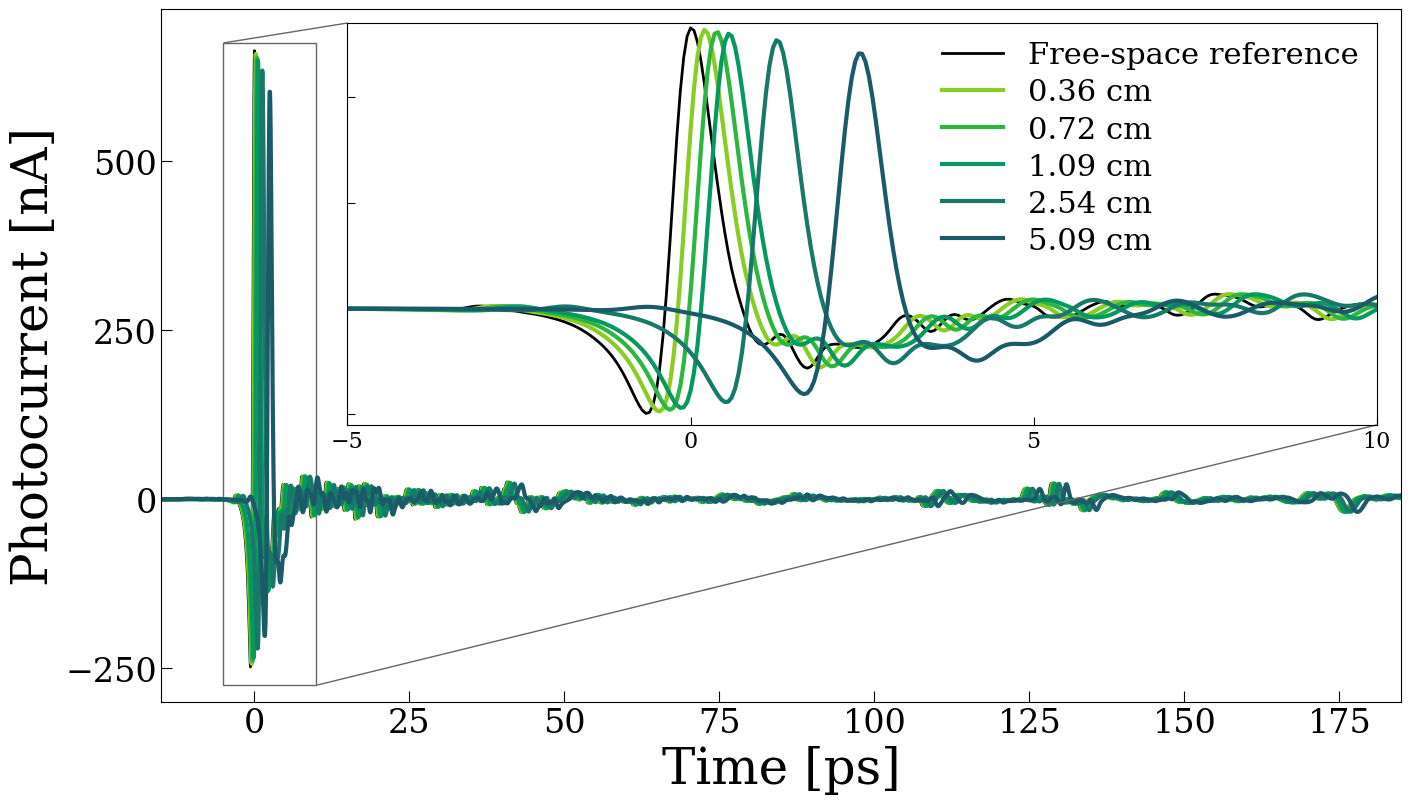

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(16, 9))

T_open,  pc_open  = site_25o4mm.get_base_pulse()

T0 = T_open[np.argmin(pc_open)]
t_ref = T_open - T0
y_ref = -pc_open

ax.set_xlim(-15, 185)

ylims = [-300, 725]
ax.set_ylim(ylims)
ax.set_yticks([-250, 0, 250, 500])
ax.xaxis.set_minor_locator(MultipleLocator(25))

ax.tick_params(axis="both", which='minor', size=4)
ax.tick_params(axis="both", which='major', size=8)

ax.set_xlabel("Time [ps]")
ax.set_ylabel("Photocurrent [nA]")

# ax.legend(frameon=False, loc="lower right", fontsize=22)

# inset
axins = inset_axes(ax, width="83%", height="58%", bbox_to_anchor=(0.15, 0.4, 1, 1), bbox_transform=ax.transAxes, loc="lower left", borderpad=0)

# plot references
ax.plot(t_ref, y_ref, color="k", lw=2, label="Free-space reference")
axins.plot(t_ref, y_ref, color="k", lw=2, label="Free-space reference")

# plot *all* samples in inset
for s in HD30_batch3.keys():
    width_cm = f"{HD30_batch3[s]['width']:.2f} cm"
    ax.plot(HD30_batch3[s]["T"] - T0, -HD30_batch3[s]["pc"], color=HD30_batch3[s]['color'], lw=3, label=width_cm)
    axins.plot(
        HD30_batch3[s]["T"] - T0,
        -HD30_batch3[s]["pc"],
        color=HD30_batch3[s]['color'],
        ls='-',
        lw=3,
        label=width_cm
    )

x1, x2 = -5, 10
axins.set_xlim(x1, x2)
axins.set_ylim([-275, 675])

axins.legend(frameon=False, loc="upper right", fontsize=22, handlelength=2.0, labelspacing=0.3, borderaxespad=0.2)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=1)

axins.set_xticks([-5, 0, 5, 10])
axins.set_yticks([-250, 0, 250, 500], labels=[])

axins.tick_params(axis="both", size=6, labelsize=16)

fig.patch.set_facecolor("white")
# plt.savefig("HD30_time_domain_inset.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## Phase

In [45]:
# These samples have easily fixable phase jumps at high frequencies that are visually confusing to readers
bugged_batches = ['HD30 batch3 5.09 cm', 'LD15 batch2 0.30 cm', 'LD24 batch2 0.34 cm']
peak_nums = [1, 0, 0] # The index of the peak corresponding to bug

i = 0
for bname, b in batches.items():
    for sample in b:
        if bname == 'HD60 2.03 cm':
            phase_diff = np.unwrap(np.unwrap(b[sample]['theta']) - np.unwrap(b[sample]['theta_base']))
            while phase_diff[0] < 0:
                phase_diff += 2*np.pi
            while phase_diff[0] >= 2*np.pi:
                phase_diff -= 2*np.pi
            phase_diff -= phase_diff[0]
        else:
            phase_diff = b[sample]['theta'] - b[sample]['theta_base']
            while phase_diff[20] < 0:
                phase_diff += 2*np.pi
            while phase_diff[20] >= 2*np.pi:
                phase_diff -= 2*np.pi

        b[sample]['phase_diff'] = phase_diff

        if sample in bugged_batches: # Manually correct an easily fixable phase jump at 1719.6 GHz in this sample
            dtheta = np.diff(b[sample]['phase_diff'])
            Abs_dtheta = np.abs(dtheta)
            peaks, props = find_peaks(Abs_dtheta, height=0.5, distance=10)

            peak_num = peak_nums[i]
            idxs = np.arange(len(b[sample]['phase_diff'])) > peaks[peak_num]
            b[sample]['phase_diff'][idxs] += 2*np.pi
            i += 1
        

        b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)
        b[sample]['n'] = 1 + b[sample]['delta_L']/b[sample]['width']*100 # convert to cm

        # Mask diffuse scatter regions in dense foams
        if bname == 'HD80 1" (25.8 mm)':
            ulim = 1390
        elif bname == 'HD110 0.8" (20.8 mm)':
            ulim = 545
        else:
            ulim = 2000

        freq_mask = (b[sample]['f'] <= ulim) # Can change if phase errors occur at high frequencies
        mask_n = freq_mask & (~b[sample]['mask'])

        b[sample]['n_masked'] = b[sample]['n'][mask_n]

        if sample == 'HD30 Batch1 2x1/8" (6.83 mm)':
            continue # Exclude this outlier sample from averaging
        
        b[sample]['n_eff'] = np.average(b[sample]['n_masked'], weights=b[sample]['t'][mask_n])
        b[sample]['n_eff_err'] = np.sqrt(np.average((b[sample]['n_masked'] - b[sample]['n_eff'])**2, weights=b[sample]['t'][mask_n]))

    valid = [sample for sample in b if sample != 'HD30 Batch1 2x1/8" (6.83 mm)']

    ## Each average is weighted by the inverse variance is the materials are homogenous.
    comb_batches[bname]['n_eff'] = np.average([b[sample]['n_eff'] for sample in valid], weights=[1/b[sample]['n_eff_err']**2 for sample in valid])
    
    propagated_err = np.sqrt(1 / np.sum([1/b[sample]['n_eff_err']**2 for sample in valid]))
    scatter_err = np.sqrt(np.average([(b[sample]['n_eff'] - comb_batches[bname]['n_eff'])**2 for sample in valid], weights=[1/b[sample]['n_eff_err']**2 for sample in valid]))
    comb_batches[bname]['n_eff_err'] = max(propagated_err, scatter_err)


## Evenly weight the batches within each material type
zote_neff2 = np.mean([comb_batches[sample]['n_eff'] for sample in comb_batches if sample in HD30_batches])
propagated_err = np.sqrt(np.sum([comb_batches[sample]['n_eff_err']**2 for sample in comb_batches if sample in HD30_batches])) / len(HD30_batches)
scatter_err = np.sqrt(np.mean([(comb_batches[sample]['n_eff'] - zote_neff2)**2 for sample in comb_batches if sample in HD30_batches]))
zote_neff2_err = max(propagated_err, scatter_err)

styro_neff2 = np.mean([comb_batches[sample]['n_eff'] for sample in comb_batches if sample in styro_batches])
propagated_err = np.sqrt(np.sum([comb_batches[sample]['n_eff_err']**2 for sample in comb_batches if sample in styro_batches])) / len(styro_batches)
scatter_err = np.sqrt(np.mean([(comb_batches[sample]['n_eff'] - styro_neff2)**2 for sample in comb_batches if sample in styro_batches]))
styro_neff2_err = max(propagated_err, scatter_err)

print(f"""
Zotefoams: n_eff = {zote_neff2:.3f} ± {zote_neff2_err:.3f}
Styrofoams: n_eff = {styro_neff2:.3f} ± {styro_neff2_err:.3f}
""")


Zotefoams: n_eff = 1.016 ± 0.002
Styrofoams: n_eff = 1.019 ± 0.002



C:\Users\alexg\AppData\Local\Temp\ipykernel_36760\629818212.py:35: RuntimeWarning: invalid value encountered in divide
  b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)
C:\Users\alexg\AppData\Local\Temp\ipykernel_36760\629818212.py:35: RuntimeWarning: divide by zero encountered in divide
  b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)


In [46]:
for bname, b in comb_batches.items():
    print(f"{bname}: n_eff = {b['n_eff']:.5f} ± {b['n_eff_err']:.2e}")

Styrofoam_batch: n_eff = 1.01941 ± 2.41e-03
LD15 batch1 2.65 cm: n_eff = 1.00891 ± 1.48e-05
LD15_batch2: n_eff = 1.00718 ± 6.08e-04
LD24 batch1 2.60 cm: n_eff = 1.01149 ± 2.13e-05
LD24_batch2: n_eff = 1.01212 ± 2.61e-04
HD30_batch1: n_eff = 1.01885 ± 2.26e-03
HD30_batch2: n_eff = 1.01355 ± 9.87e-04
HD30_batch3: n_eff = 1.01427 ± 3.83e-04
PP35 0.32 cm: n_eff = 1.01800 ± 7.31e-05
HD80 2.58 cm: n_eff = 1.03932 ± 2.04e-04
HD110 2.08 cm: n_eff = 1.06345 ± 7.28e-04


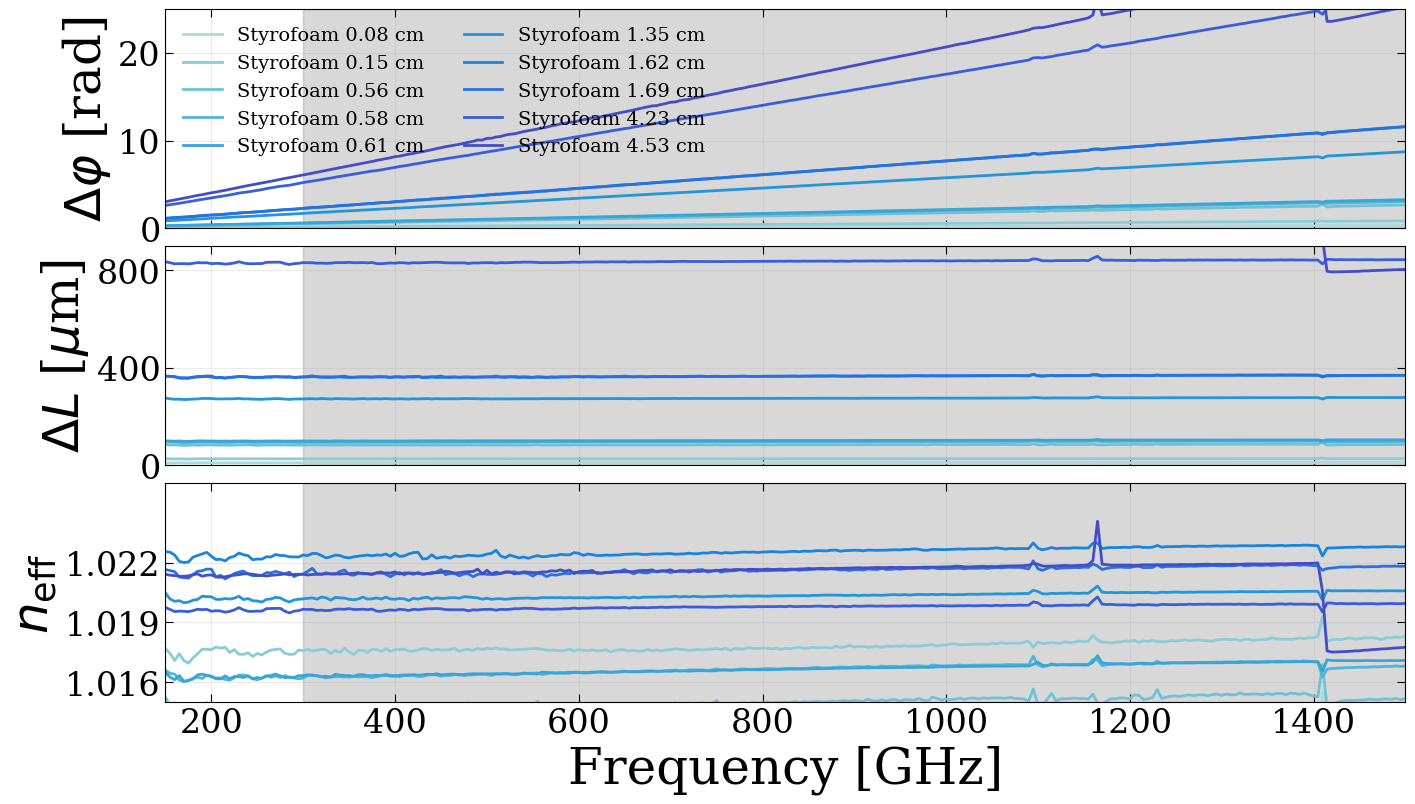

In [47]:
fig, axs = plt.subplots(
    3, 1, sharex=True, figsize=(16, 9),
    gridspec_kw=dict(height_ratios=[1, 1, 1], hspace=0.08)
)

for bname, b in batches.items():
    if "Styrofoam" not in bname:
        continue
    for sample in b:
        axs[0].plot(b[sample]['f'], b[sample]['phase_diff'], color=b[sample]['color'], lw=2, label=sample)
        axs[1].plot(b[sample]['f'], b[sample]['delta_L']*1e6, color=b[sample]['color'], lw=2, label=sample)
        axs[2].plot(b[sample]['f'], b[sample]['n'], lw=2, color=b[sample]['color'], label=sample)

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]')
axs[1].set_ylabel(r'$\Delta L$ [$\mu$m]')
axs[2].set_ylabel(r'$n_{\rm eff}$')
axs[2].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(150, 1500)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
    ax.tick_params(direction='in', length=6, top=True, right=True)

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue
    # else:
    #     axs[0].text((i+j)/2, 25, 'H$_2$O', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')

axs[0].set_ylim(0, 25)
axs[1].set_ylim(0, 900)
axs[2].set_ylim(1.015, 1.026)
axs[1].set_yticks([0, 400, 800])
axs[2].set_yticks([1.016, 1.019, 1.022])
# Legend (single, clean)
axs[0].legend(loc='upper left', fontsize=14, edgecolor='k', frameon=False, ncol=2)

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()
plt.show()


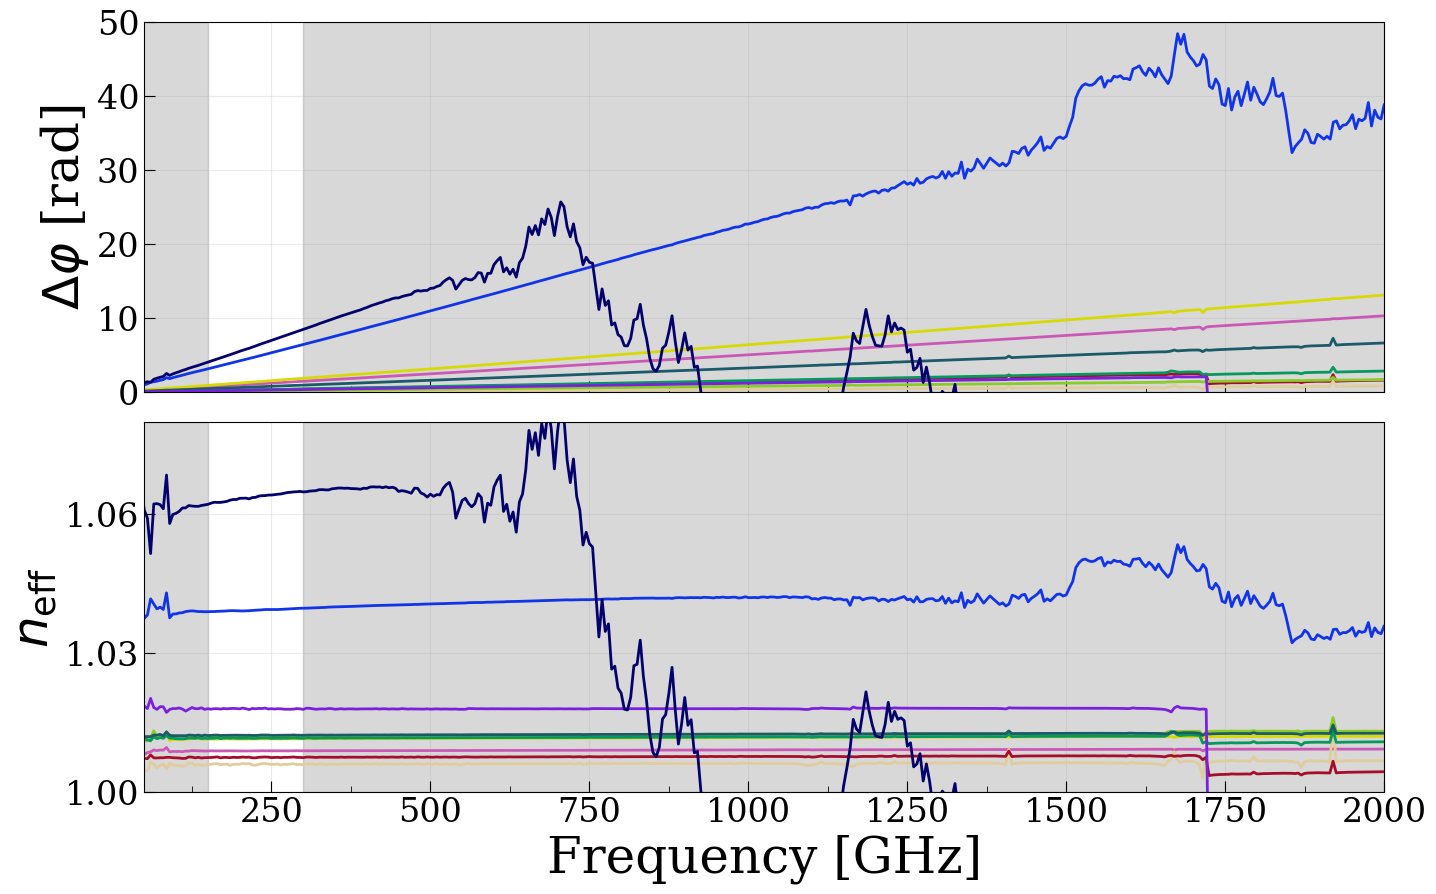

In [48]:
fig, axs = plt.subplots(
    2, 1, sharex=True, figsize=(16, 10),
    gridspec_kw=dict(height_ratios=[1, 1], hspace=0.08)
)

for bname, b in batches.items():
    if bname not in other_zote_keys or bname == 'HD60 2.03 cm':
        continue
    for sample in b:
        color = b[sample]['color']

        axs[0].plot(b[sample]['f'], b[sample]['phase_diff'],  color=color, lw=2, label=sample)
        axs[1].plot(b[sample]['f'], b[sample]['n'],           color=color, lw=2, label=sample)

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]')
axs[1].set_ylabel(r'$n_{\rm eff}$')
axs[1].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(50, 2000)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
axs[1].xaxis.set_major_locator(MultipleLocator(250))
axs[1].xaxis.set_minor_locator(MultipleLocator(125))

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue

axs[0].set_ylim(0, 50)
axs[1].set_ylim(1, 1.08)
axs[1].set_yticks([1, 1.03, 1.06])

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()

plt.show()

## Frequency Domain

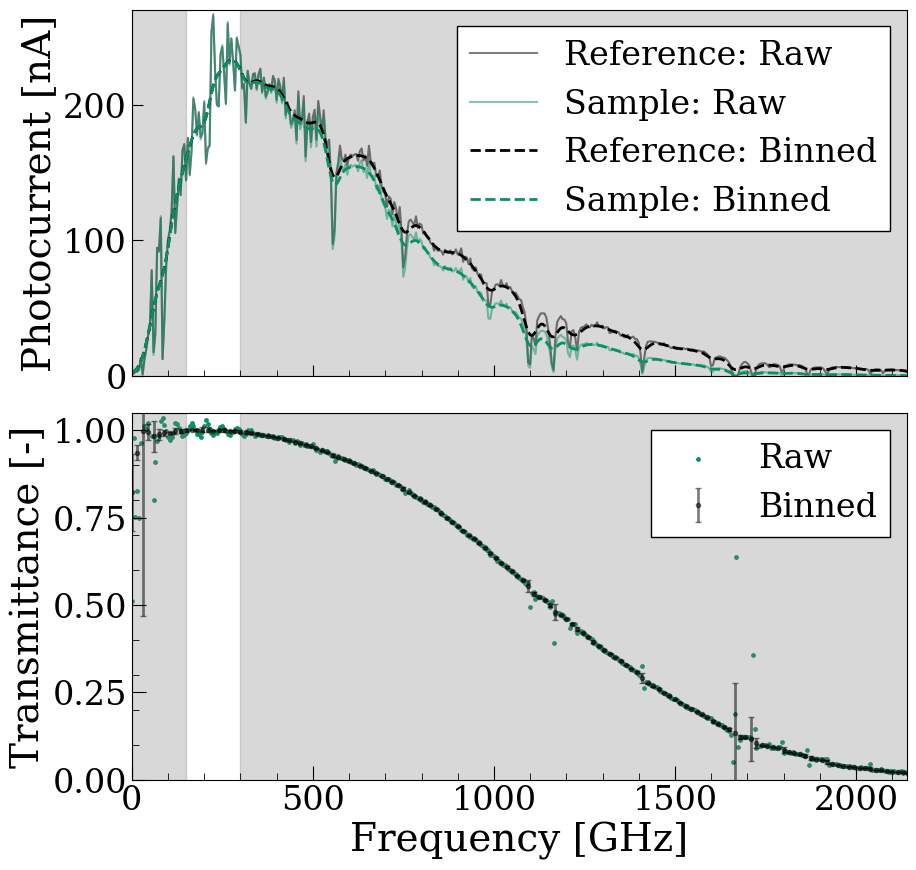

In [49]:
_, samp_amp = site_25o4mm.get_sample_current()
_, ref_amp  = site_25o4mm.get_base_current()

samp_amp_smoothed = getattr(site_25o4mm, 'bcsamp')
ref_amp_smoothed  = getattr(site_25o4mm, 'bcbase')
mes_err           = getattr(site_25o4mm, 'mes_err')

# Plot measurements and fits
sample = 'HD30 batch3 2.54 cm'
data = HD30_batch3[sample]

color = comb_batches["HD30_batch3"]['color']

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

ax0, ax1 = axs

ax0.plot(data['f'], ref_amp, color='k', alpha=0.5, label='Reference: Raw')
ax0.plot(data['f'], samp_amp, color=color, alpha=0.5, label='Sample: Raw')
ax0.plot(data['f'], ref_amp_smoothed, color='k', linestyle='--', linewidth=2, label='Reference: Binned')
ax0.plot(data['f'], samp_amp_smoothed, color=color, linestyle='--', linewidth=2, label='Sample: Binned')
# ax1.plot(data['f'], mes_err, color='cyan', linestyle='-', linewidth=2, label='Photon noise floor', zorder=10)

ax1.scatter(data['f'], data['ut'], color=color, s=6, label='Raw')
ax1.errorbar(data['f'][::data['boxnum']], data['t'][::data['boxnum']], yerr=data['err'][::data['boxnum']],
        fmt='o', markersize=3, linewidth=2, capsize=2, color='k', alpha=0.5, label='Binned')
    # plt.plot(data[sample]['f'], data[sample]['cf'], color='k', linestyle='--', linewidth=2, alpha=0.7, zorder=10, label=r'Rayleigh $\times$ Mie Model' if i == len(data)-1 else None)
data_handles, data_labels = plt.gca().get_legend_handles_labels()

xlims = (0, 2140)

for i, j in zip(mask_starts, mask_stops):
    for ax in axs:
        ax.axvspan(i, j, color='gray', alpha=0.3)
    if (i == 0):
        # ax0.text((xlims[0]+j)/2, 270, 'Instr.\nLimit', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')
        continue
    elif (j == 10000):
        # ax0.text((i+xlims[1])/2, 270, 'Instr.\nLimit', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')
        continue
    else:
        ax0.text((i+j)/2, 270, 'H$_2$O', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')


handles, labels = plt.gca().get_legend_handles_labels()
misc_handles = [handle for handle in handles if handle not in data_handles]
custom_line = [mpl.lines.Line2D([0], [1], color='lime', linestyle='--', label='Fitted data')]

# plt.legend(handles=data_handles + custom_line + misc_handles, edgecolor='black', fontsize=16, loc='upper right')
ax0.legend(fontsize=24, loc='upper right', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)
ax1.legend(fontsize=24, loc='upper right', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

ax1.set_xlim(xlims)
# ax0.set_yscale('log')
# ax1.set_yscale('log')
ax0.set_ylim(0, 270)
ax1.set_ylim(0, 1.05)
# ax1.set_ylim(1e-4, 1e0)
# ax1.set_ylim(0, 1.02)
ax1.yaxis.set_minor_locator(MultipleLocator(0.1))
ax0.xaxis.set_minor_locator(MultipleLocator(100))
plt.tick_params(axis='both', which='major', size=10)
plt.tick_params(axis='both', which='minor', size=5)
ax1.set_xlabel('Frequency [GHz]', fontsize=28)
ax0.set_ylabel('Photocurrent [nA]', fontsize=28)
ax1.set_ylabel('Transmittance [-]', fontsize=28)
plt.gcf().set_facecolor('white')
plt.subplots_adjust(hspace=0.1)

# plt.savefig('ut_vs_t_example.pdf', bbox_inches='tight', facecolor='white')
plt.show()

# Model functions

In [50]:
def IRBF_comp(f, params, width, n):
    lt, C, K_Ray, K_Mie = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    return np.exp(-width*loss), np.exp(-width*Ray), np.exp(-width*Mie)

def IRBF_components(f, params, width, n):
    lt, C, K_Ray, K_Mie = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    Ray_perc  = 100*(1 - np.exp(-width*Ray))
    Mie_perc  = 100*(1 - np.exp(-width*Mie))
    return Abs_perc, Ray_perc, Mie_perc

def IRBF_abs(f, lt, width, n):
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    return Abs_perc

def chi2_dof(f, t, C, IRBF, len_params):
    chi2 = np.sum(((t - IRBF)/C)**2)
    dof  = len(f) - len_params
    return chi2/dof

Numba just in time (`njit`) version for efficient sampling

In [51]:
from numba import njit, prange

c = float(const.c)

@njit(fastmath=True)
def IRBF_njit(f, params, width, n):
    """
    f:      (Nf,) frequencies (GHz or whatever you're using; just be consistent)
    params: (4,)  [lt, C, K_Ray, K_Mie]
    width:  scalar sample width (cm)
    n:      scalar refractive index
    returns (Nf,)
    """
    lt, C, K_Ray, K_Mie = params

    # Rayleigh ~ C * (f / K_Ray)^4
    f2  = f * f
    f4  = f2 * f2
    KR4 = K_Ray**4
    Ray = C * f4 / KR4

    # Mie term: C * (2 - 4/(f / K_Mie) sin(f / K_Mie) + 4/(f / K_Mie)^2 (1 - cos(f / K_Mie)))
    f_over_k   = f / K_Mie
    sin_ = np.sin(f_over_k)
    cos_ = np.cos(f_over_k)
    inv  = 1.0 / (f_over_k)
    inv2 = inv * inv
    Mie  = C * (2.0 - 4.0 * (sin_ * inv) + 4.0 * ((1.0 - cos_) * inv2))

    # dielectric loss: 2e7 * pi * n * lt * f / c
    loss = (2.0e7 * np.pi * n * lt / c) * f

    return np.exp(-width*(loss + Ray + Mie))

@njit(fastmath=True)
def IRBF_alpha_njit(f, params, n):
    lt, C, K_Ray, K_Mie = params

    # Rayleigh ~ (f / K_Ray)^4
    f2  = f * f
    f4  = f2 * f2
    KR4 = K_Ray**4
    Ray = C * f4 / KR4

    # Mie term: C * (2 - 4/(f / K_Mie) sin(f / K_Mie) + 4/(f / K_Mie)^2 (1 - cos(f / K_Mie)))
    f_over_k   = f / K_Mie
    sin_ = np.sin(f_over_k)
    cos_ = np.cos(f_over_k)
    inv  = 1.0 / (f_over_k)
    inv2 = inv * inv
    Mie  = C * (2.0 - 4.0 * (sin_ * inv) + 4.0 * ((1.0 - cos_) * inv2))

    # dielectric loss: 2e7 * pi * n * lt * f / c
    loss = (2.0e7 * np.pi * n * lt / c) * f

    return loss + Ray + Mie

## Nested Sampling

In [52]:
from fitting_funcs import IRBF_njit, IRBF_alpha_njit, fitting

def IRBF_comp(f, params, width, n):
    lt, C, K_Ray, K_Mie, a_RM = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    res_RM   = 2*a_RM*Ray*Mie/C
    return np.exp(-width*loss), np.exp(-width*Ray), np.exp(-width*Mie), np.exp(width*res_RM)

def IRBF_components(f, params, width, n):
    lt, C, K_Ray, K_Mie, a_RM = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    Ray_perc  = 100*(1 - np.exp(-width*Ray))
    Mie_perc  = 100*(1 - np.exp(-width*Mie))
    res_RM   = (np.exp(width*2*a_RM*Ray*Mie/C))
    return Abs_perc, Ray_perc, Mie_perc, res_RM

def IRBF_abs(f, lt, width, n):
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    return Abs_perc

def chi2_dof(f, t, C, IRBF, len_params):
    chi2 = np.sum(((t - IRBF)/C)**2)
    dof  = len(f) - len_params
    return chi2/dof

############# Configure to adjust the nested sampling #############
nlive = 10000
dlogz = 0.01
ncpu  = 16

## Batch Fits

In [53]:
for bname, b in comb_batches.items():
    bname_cleaned = bname.replace(" ", "_").replace('"', 'in')
    fpath = f'pkls/{bname_cleaned}_model_300GHz.pkl'

    if os.path.exists(fpath):
        with open(fpath, 'rb') as file:
            results = pickle.load(file)
            if results.nlive >= nlive:
                b['weights'] = np.exp(results['logwt'] - results['logz'][-1])
                b['samples'] = dynesty.utils.resample_equal(results.samples, b['weights'])
                print(f'Number of posterior {bname} samples:', len(b['samples']))
                continue

    f_    = b['f_comb']
    t     = b['t_comb']
    width = b['width_comb']
    err   = b['err_comb']
    n_eff = b['n_eff']
    results = fitting(f_, t, width, err, n_eff, nlive, dlogz, ncpu=ncpu)

    results.summary()

    b['weights'] = np.exp(results['logwt'] - results['logz'][-1])
    b['samples'] = dynesty.utils.resample_equal(results.samples, b['weights'])
    print(f'Number of posterior {bname} samples:', len(b['samples']))

    # Save the results
    with open(fpath, 'wb') as file:
        pickle.dump(results, file)

Running Nested Sampling...


129740it [01:53, 1139.66it/s, +10000 | bound: 31 | nc: 1 | ncall: 4803205 | eff(%):  2.915 | loglstar:   -inf < 362.988 <    inf | logz: 354.624 +/-    nan | dlogz:  0.000 >  0.010]


Summary
nlive: 10000
niter: 129740
ncall: 4793205
eff(%):  2.915
logz: 354.624 +/-  0.026
Number of posterior Styrofoam_batch samples: 139740
Running Nested Sampling...


140574it [01:59, 1175.49it/s, +10000 | bound: 34 | nc: 1 | ncall: 5299683 | eff(%):  2.847 | loglstar:   -inf < 58.870 <    inf | logz: 49.423 +/-    nan | dlogz:  0.000 >  0.010]  


Summary
nlive: 10000
niter: 140574
ncall: 5289683
eff(%):  2.847
logz: 49.423 +/-  0.029
Number of posterior LD15 batch1 2.65 cm samples: 150574
Running Nested Sampling...


...

Summary
nlive: 10000
niter: 103188
ncall: 3220105
eff(%):  3.515
logz: 49.821 +/-  0.023
Number of posterior PP35 0.32 cm samples: 113188
Running Nested Sampling...


225189it [02:16, 1652.16it/s, +10000 | bound: 53 | nc: 1 | ncall: 8623000 | eff(%):  2.731 | loglstar:   -inf < -758.359 <    inf | logz: -776.268 +/-  0.040 | dlogz:  0.000 >  0.010]


Summary
nlive: 10000
niter: 225189
ncall: 8613000
eff(%):  2.731
logz: -776.268 +/-  0.041
Number of posterior HD80 2.58 cm samples: 235189
Running Nested Sampling...


228575it [02:30, 1521.35it/s, +10000 | bound: 63 | nc: 1 | ncall: 9521521 | eff(%):  2.508 | loglstar:   -inf < 35.590 <    inf | logz: 17.342 +/-    nan | dlogz:  0.000 >  0.010]


Summary
nlive: 10000
niter: 228575
ncall: 9511521
eff(%):  2.508
logz: 17.342 +/-  0.040
Number of posterior HD110 2.08 cm samples: 238575


In [54]:
from fitting_funcs import IRBF_batch_params, alpha_batch_params, components_batch_params

alphas = {}

for bname, b in comb_batches.items():
    bname_cleaned = bname.replace(" ", "_").replace('"', 'in')
    fpath = f'pkls/{bname_cleaned}_alpha_300GHz.pkl'

    if os.path.exists(fpath):
        with open(fpath, 'rb') as file:
            b['alpha_lower'], b['ns_alpha'], b['alpha_upper'] = pickle.load(file)
    else:
        alpha = alpha_batch_params(f, b['samples'], b['n_eff'])
        b['alpha_lower'], b['ns_alpha'], b['alpha_upper'] = np.percentile(alpha, [16, 50, 84], axis=0)
        with open(fpath, 'wb') as file:
            pickle.dump((b['alpha_lower'], b['ns_alpha'], b['alpha_upper']), file)

In [55]:
w = 5 # 5 cm assembly example

for bname, b in comb_batches.items():
    q = np.percentile(b['samples'], [16, 50, 84], axis=0)

    b['params']    = q[1]
    b['upper_params'] = q[2] - q[1]
    b['lower_params'] = q[1] - q[0]
    b['C_params'] = (q[2] - q[0])/2
    b[f'T_upper_5cm'], b[f'ns_T_5cm'], b[f'T_lower_5cm'] = np.exp(-w*b['alpha_lower']), np.exp(-w*b['ns_alpha']), np.exp(-w*b['alpha_upper'])

    n_eff = b['n_eff']

    for sample_name, sample in batches[bname].items():
        ## transform samples from parameter space to transmission
        width = sample['width']
        sample['T_upper'], sample['ns_T'], sample['T_lower'] = np.exp(-width*b['alpha_lower']), np.exp(-width*b['ns_alpha']), np.exp(-width*b['alpha_upper'])
        diff = sample['T_upper'] - sample['T_lower']

## Combined Sampling Results

In [56]:
def round_uncertainty(x):
    """Return (rounded_value, decimal_places_for_round())."""
    x = float(x)
    if x == 0.0:
        return 0.0, 0

    exponent = int(np.floor(np.log10(abs(x))))

    # first_digit = abs(x) / 10**exponent
    # sigfigs = 2 if first_digit < 1.95 else 1
    sigfigs = 1
    
    decimals = int(sigfigs - 1 - exponent)  # can be negative!

    return round(x, decimals), decimals

def sci_scale(x):
    """
    Return (scaled_x, exponent) such that:
    x = scaled_x * 10**exponent
    """
    if x == 0:
        return 0.0, 0
    exponent = int(np.floor(np.log10(abs(x))))
    return x / 10**exponent, exponent

def format_unc(mu, C_minus, C_plus, sci_thresh=1e-3):
    mu = float(mu)
    C_minus = float(C_minus)
    C_plus  = float(C_plus)

    use_sci = abs(mu) < sci_thresh and mu != 0

    if use_sci:
        mu_s, exp = sci_scale(mu)
        sm_s = C_minus / 10**exp
        sp_s = C_plus  / 10**exp
    else:
        mu_s, sm_s, sp_s = mu, C_minus, C_plus
        exp = None

    # Determine rounding from uncertainties
    _, d1 = round_uncertainty(sm_s)
    _, d2 = round_uncertainty(sp_s)
    decimals = max(d1, d2)

    mu_r = round(mu_s, decimals)
    sm_r = round(sm_s, decimals)
    sp_r = round(sp_s, decimals)

    prec = max(decimals, 0)
    fmt = f"{{:.{prec}f}}"

    core = rf"{fmt.format(mu_r)}^{{+{fmt.format(sp_r)}}}_{{-{fmt.format(sm_r)}}}"

    if use_sci:
        return rf"${core}\times10^{{{exp}}}$"
    else:
        return rf"${core}$"
    
def format_unc_1sided(mu, C, sci_thresh=1e-3, shorthand=True):
    mu = float(mu)
    C = float(C)

    use_sci = abs(mu) < sci_thresh and mu != 0

    if use_sci:
        mu_s, exp = sci_scale(mu)
        C_s = C / 10**exp
    else:
        mu_s, C_s = mu, C
        exp = None

    _, decimals = round_uncertainty(C_s)
    mu_r = round(mu_s, decimals)
    C_r = round(C_s, decimals)

    prec = max(decimals, 0)
    fmt = f"{{:.{prec}f}}"

    if shorthand and not use_sci:
        ### e.g. 1.013(1) for 1.013 ± 0.001
        C_int = round(C_r * 10**prec)
        core = rf"{fmt.format(mu_r)}({C_int})"
        return rf"${core}$"

    core = rf"{fmt.format(mu_r)} \pm {fmt.format(C_r)}"

    if use_sci:
        return rf"${core}\times10^{{{exp}}}$"
    else:
        return rf"${core}$"
    
def format_val(val, sci_thresh=1e-2):
    val = float(val)
    
    use_sci = abs(val) < sci_thresh and val != 0

    if use_sci:
        exp = int(np.floor(np.log10(abs(val))))
        core = val / 10**exp
        return rf"${core:.1f}\times10^{{{exp}}}$"
    else: 
        return rf"${val:.2f}$"


def get_corner_handles(bs, type=None):
    handles = []
    
    for b in bs:
        if type == None:
            sample_cleaned = b.replace('_', ' ')
        elif type == 'HD30':
            sample_cleaned = b.replace('_', ' ').replace('HD30 ', '').replace('batch', 'Batch ')
        elif type == 'Styrofoam':
            sample_cleaned = b.replace('_', ' ').replace('Styrofoam', '').replace('batch', 'Batch ')
        else:
            raise ValueError("type must be None, 'HD30', or 'Styrofoam'")
        base = comb_batches[b]['color']

        # Convert to RGBA and make a lighter facecolor (blend with white)
        r, g, b, a = mcolors.to_rgba(base)
        light = (0.5 + 0.5*r, 0.5 + 0.5*g, 0.5 + 0.5*b, 0.9)
        dark  = (r, g, b, 1.0)                             

        # Zero-size Rectangle proxy like anesthetic (width/height don't matter for legend)
        patch = mpatches.Rectangle(
            (0, 0), 0, 0,
            facecolor=dark,
            edgecolor=light,
            linewidth=4,
            label=sample_cleaned,
        )
        handles.append(patch)

    return handles

PP35 0.32 cm


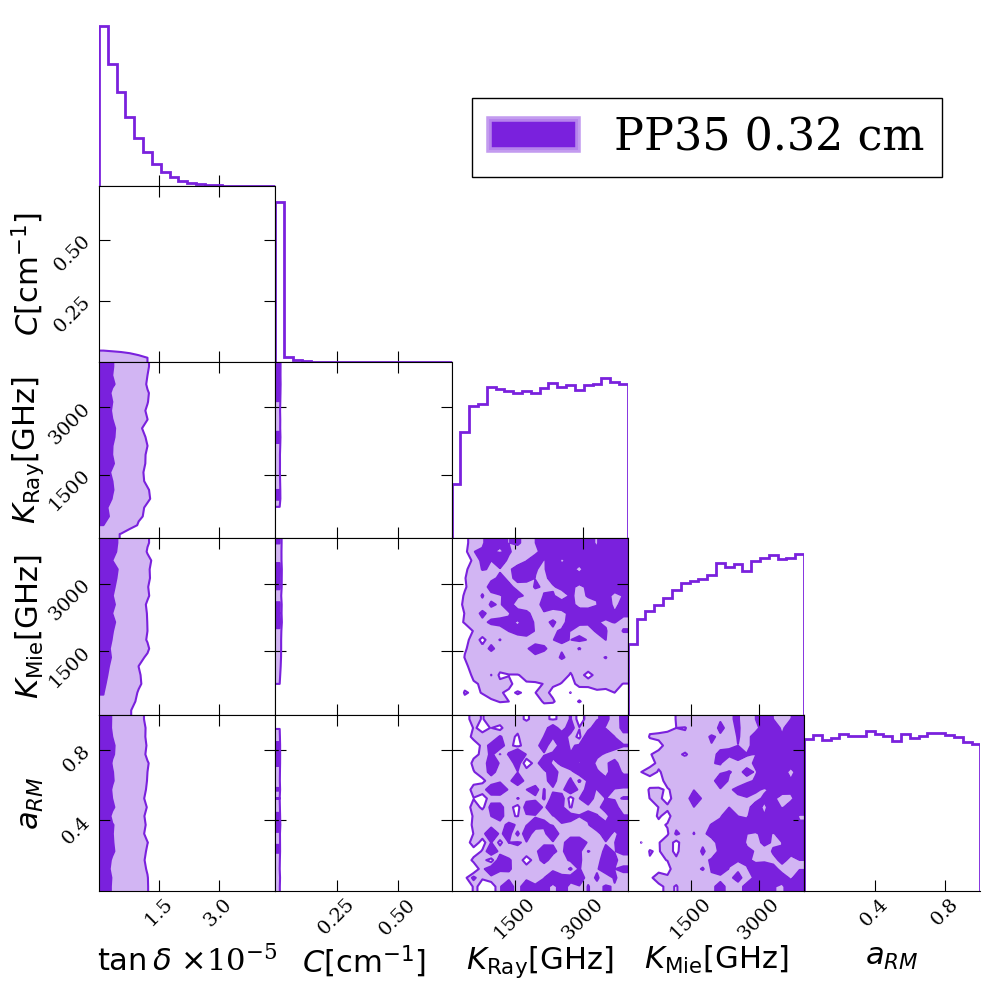

In [57]:
param_names = [r'$\tan\delta$', r'$C [\mathrm{cm}^{-1}]$', r'$K_{\mathrm{Ray}} [\mathrm{GHz}]$', r'$K_{\mathrm{Mie}} [\mathrm{GHz}]$', r'$a_{RM}$']

figure = plt.figure(figsize=(10,10))

for bname, b in comb_batches.items():
    if bname != 'PP35 0.32 cm':
        continue

    print(bname)

    samples      = b['samples']
    color        = b['color']

    fig = corner.corner(samples, 
                    show_titles=False, 
                    labels = param_names,            
                    use_math_text = True,
                    label_kwargs={"fontsize": 22},
                    max_n_ticks=3,
                    plot_datapoints=False,
                    show_median=False,
                    show_mean=False,
                    plot_density=False,
                    levels=[0.393, 0.864],
                    fill_contours=True,
                    color=color,
                    hist_kwargs={"linewidth": 2},
                    fig=figure)

for i, ax in enumerate(fig.axes):
    ax.tick_params(axis='both', labelsize=14)
    if i == 0:
        ax.spines['left'].set_visible(False)
    row, col = divmod(i, len(param_names))
    if col < row:
        ax.xaxis.set_tick_params(which='both', direction='in', top=True)
        ax.yaxis.set_tick_params(which='both', direction='in', right=True)
    if col == row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('white')

figure.canvas.draw()

for ax in figure.get_axes():
    if ax.xaxis.get_offset_text().get_text() != '':
        offset = ax.xaxis.get_offset_text().get_text()
        ax.set_xlabel(ax.get_xlabel() + f' {offset}', fontsize=22)
        ax.xaxis.get_offset_text().set_visible(False)
        
    if ax.yaxis.get_offset_text().get_text() != '':
        offset = ax.yaxis.get_offset_text().get_text()
        ax.set_ylabel(ax.get_ylabel() + f' {offset}', fontsize=22)
        ax.yaxis.get_offset_text().set_visible(False)

handles = get_corner_handles(['PP35 0.32 cm'])

fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.95, 0.90), fontsize=32, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

fig.subplots_adjust(hspace=0, wspace=0)
plt.gcf().set_facecolor('white')
# plt.savefig('styro_params-b.pdf', bbox_inches='tight', facecolor='white')
plt.show()

Get band averages from the estimates

In [58]:
def f_p_from_rho(rho_eff, rho_p, rho_m=1.25):
    """Matrix volume fraction from density mixing: rho_eff = f_p rho_p + (1-f_p) rho_m."""
    return (rho_eff - rho_m) / (rho_p - rho_m)

def lt_eff(f_p, n_p, tan_delta_p, n_eff, n_m=1.0003):
    """
    Maxwell–Garnett (dilute polymer inclusions in gas host) effective loss tangent.
    tanδ_eff = n_p^2 * (n_n_eff^2 + 2n_m^2)^2 / [n_eff^2 * (n_p^2 + 2n_m^2)^2] * f_p tanδ_p
    """
    num = n_p**2*(n_eff**2 + 2*n_m**2)**2
    den = n_eff**2*(n_p**2   + 2*n_m**2)**2
    return (num / den) * f_p * tan_delta_p

for bname, b in comb_batches.items():

    ## Estimate the loss tangent
    if "HD" in bname:
        b['rho_p'] = 950
        lt_p = 2.5e-4   # HDPE loss tangent from literature
        b['n_p'] = 1.54
        
    elif "LD" in bname:
        b['rho_p'] = 925
        lt_p  = 2.7e-4
        b['n_p']   = 1.514  # Literature estimates this value as slightly lower...
        
    elif "Styrofoam" in bname:
        b['rho_p'] = 1050
        lt_p = 6.9e-3       # Polystyrene loss tangent from literature
        b['n_p']   = 1.59
    elif "PP" in bname:
        b['rho_p'] = 905
        lt_p       = 6.2e-4       # Polypropylene loss tangent from literature
        b['n_p']   = 1.5
    else:
        raise ValueError(f"Unknown material type: {bname}")

    b['f_p'] = f_p_from_rho(b['density'], b['rho_p'])
    b['lt']  = lt_eff(b['f_p'], b['n_p'], lt_p, b['n_eff'])

In [59]:
band_windows = {
    "30":  (24, 30),
    "40":  (30, 47),
    "90":  (75, 110),
    "150": (120, 165),
    "220": (195, 255),
    "280": (260, 305),
}

for bname, b in comb_batches.items():
    print(bname)
    ## Constrain the components
    params       = b["params"]
    upper_params = b["upper_params"]
    lower_params = b["lower_params"]
    n_eff        = b["n_eff"]
    lt           = b["lt"]

    bname_cleaned = bname.replace(" ", "_").replace('"', 'in')
    fpath = f'pkls/{bname_cleaned}_components_300GHz.pkl'

    if os.path.exists(fpath):
        with open(fpath, 'rb') as file:
            (Abs_lower, Abs, Abs_upper,
             Ray_lower, Ray, Ray_upper,
             Mie_lower, Mie, Mie_upper,
             res_lower, res, res_upper) = pickle.load(file)
    else:
        Abs_s, Ray_s, Mie_s, res_s = components_batch_params(f, b['samples'], w, n_eff)

        Abs_lower, Abs, Abs_upper = np.percentile(Abs_s, [16, 50, 84], axis=0)
        Ray_lower, Ray, Ray_upper = np.percentile(Ray_s, [16, 50, 84], axis=0)
        Mie_lower, Mie, Mie_upper = np.percentile(Mie_s, [16, 50, 84], axis=0)
        res_lower, res, res_upper = np.percentile(res_s, [16, 50, 84], axis=0)

        with open(fpath, 'wb') as file:
            pickle.dump((Abs_lower, Abs, Abs_upper,
                         Ray_lower, Ray, Ray_upper,
                         Mie_lower, Mie, Mie_upper,
                         res_lower, res, res_upper), file)

    # Bookmark
    Abs_lower = np.zeros_like(Abs_lower)
    Abs = IRBF_abs(f, lt, w, n_eff)
    Abs_upper = 2*Abs

    estimates = {
        "Abs": dict(arr=Abs, upper=Abs_upper, lower=Abs_lower, color='tab:red',    ls='-'),
        "Ray":  dict(arr=Ray,  upper=Ray_upper,  lower=Ray_lower,  color='tab:blue',   ls='--'),
        "Mie":  dict(arr=Mie,  upper=Mie_upper,  lower=Mie_lower,  color='tab:orange', ls=':'),
        "res": dict(arr=res, upper=res_upper, lower=res_lower, color='tab:green',  ls='-.'),
    }

    b["estimates"] = estimates

    band_avgs = {}
    for band, (lo_f, hi_f) in band_windows.items():
        sel = (f > lo_f) & (f < hi_f)
        
        for comp, est_data in estimates.items():
            val       = np.mean(est_data['arr'][sel])
            upper_val = np.mean(est_data['upper'][sel])
            lower_val = np.mean(est_data['lower'][sel])

            up = upper_val - val
            lo = val - lower_val

            band_avgs[(band, comp)]            = val
            band_avgs[(band, f"{comp}_upper")] = up
            band_avgs[(band, f"{comp}_lower")] = lo

    b["band_avgs"] = band_avgs

    ## Band averaged transmission with uncertainties
    T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']
    for band_name, (lo_f, hi_f) in band_windows.items():
        sel = (f > lo_f) & (f < hi_f)
        val = float(np.mean(ns_T[sel]))
        upper_val = float(np.mean(T_upper[sel]))
        lower_val = float(np.mean(T_lower[sel]))

        up = upper_val - val
        lo = val - lower_val

        b[f"T{band_name}"] = format_unc(val, lo, up)

Styrofoam_batch
LD15 batch1 2.65 cm
LD15_batch2
LD24 batch1 2.60 cm
LD24_batch2
HD30_batch1
HD30_batch2
HD30_batch3
PP35 0.32 cm
HD80 2.58 cm
HD110 2.08 cm


# Fixed Loss tangent fitting

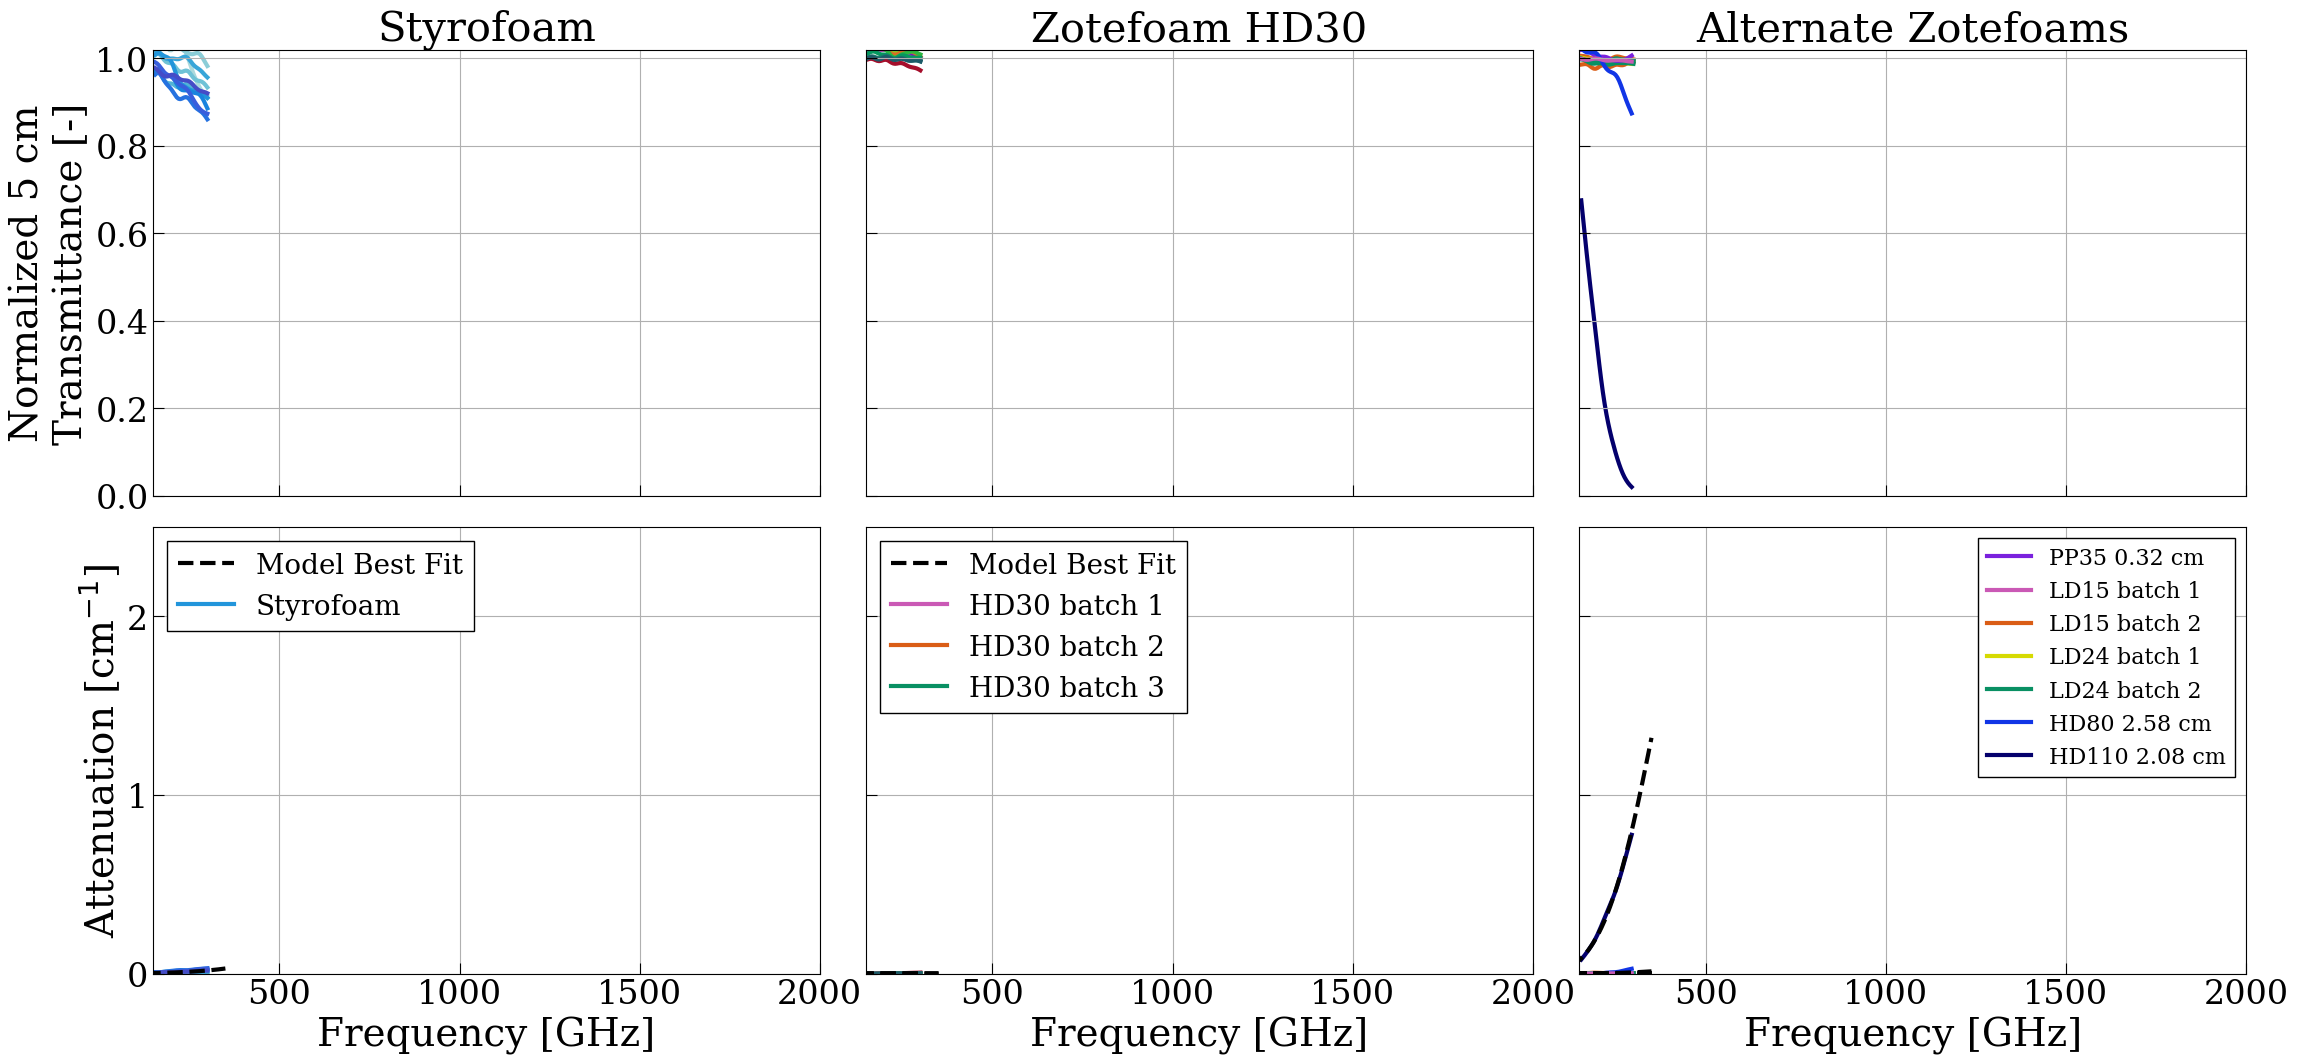

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(27, 12), sharex=True, sharey='row')

lw = 3
plt.xlim(150, 2000)
axes[0, 0].set_ylim(0, 1.02)
axes[1, 0].set_ylim(0, 2.5)
axes[0, 0].set_ylabel('Normalized 5 cm\nTransmittance [-]', fontsize=28)
axes[1, 0].set_ylabel(r'Attenuation [cm$^{-1}$]', fontsize=28)

for ax in axes[1, :]:
    ax.set_xlabel('Frequency [GHz]', fontsize=28)


for bname, b in batches.items():
    i = 0
    if bname in styro_batches:
        ax1 = axes[0, 0]
        ax2 = axes[1, 0]

    elif bname in HD30_batches:
        ax1 = axes[0, 1]
        ax2 = axes[1, 1]

    elif bname in other_zote_keys and bname != 'HD60 2.03 cm':
        ax1 = axes[0, 2]
        ax2 = axes[1, 2]

    else:
        continue

    for j, sample in enumerate(b):

        f_    = b[sample]['f']
        t     = b[sample]['t']
        alpha = b[sample]['alpha']
        err   = b[sample]['err']
        mask  = b[sample]['mask']

        ns_T = b[sample]['ns_T']
        ns_alpha = comb_batches[bname]['ns_alpha']
        width = b[sample]['width']
        ns_T_5cm = ns_T**(5/width)

        t_5cm_masked = np.where(mask, np.nan, t**(5/width))
        alpha_masked = np.where(mask, np.nan, alpha)

        if ax2 == axes[1, 2]:
            color = comb_batches[bname]['color']
        else:
            color = b[sample]['color']

        zorder=-9 if sample == 'LD15 batch1 2.65 cm' else -10

        ax1.plot(f_, t_5cm_masked, color=color, lw=lw, zorder=zorder)
        ax2.plot(f_, alpha_masked, color=color, lw=lw, zorder=zorder)

        # transform to display coordinates

        if i == 0:
            ax2.plot(f, ns_alpha, color='k', linestyle='--', lw=3, zorder=10)
            # ax1.plot(f, ns_T_5cm, color='k', linestyle='--', lw=3, zorder=10)

        i += 1


for ax in axes.flatten():
    ax.grid(True)
#     for i, j in zip(mask_starts, mask_stops):
#         ax.axvspan(i, j, facecolor='white', hatch='/', edgecolor='k', alpha=0.5, zorder=1)

custom_line = mpl.lines.Line2D([0], [1], color='k', linestyle='--', lw=3, label='Model Best Fit')

styro_line  = mpl.lines.Line2D([0], [1], color=comb_batches['Styrofoam_batch']['color'], lw=3, label='Styrofoam')

hd30_line1 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch1']['color'], lw=3, label='HD30 batch 1')
hd30_line2 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch2']['color'], lw=3, label='HD30 batch 2')
hd30_line3 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch3']['color'], lw=3, label='HD30 batch 3')

pp35_line  = mpl.lines.Line2D([0], [1], color=comb_batches['PP35 0.32 cm']['color'], lw=3, label='PP35 0.32 cm')
ld15_line1 = mpl.lines.Line2D([0], [1], color=comb_batches['LD15 batch1 2.65 cm']['color'], lw=3, label='LD15 batch 1')
ld15_line2 = mpl.lines.Line2D([0], [1], color=comb_batches['LD15_batch2']['color'], lw=3, label='LD15 batch 2')
ld24_line1 = mpl.lines.Line2D([0], [1], color=comb_batches['LD24 batch1 2.60 cm']['color'], lw=3, label='LD24 batch 1')
ld24_line2 = mpl.lines.Line2D([0], [1], color=comb_batches['LD24_batch2']['color'], lw=3, label='LD24 batch 2')
hd80_line  = mpl.lines.Line2D([0], [1], color=comb_batches['HD80 2.58 cm']['color'], lw=3, label='HD80 2.58 cm')
hd110_line = mpl.lines.Line2D([0], [1], color=comb_batches['HD110 2.08 cm']['color'], lw=3, label='HD110 2.08 cm')

handles = [custom_line, styro_line]

axes[1, 0].legend(handles=handles, loc='upper left', fontsize=20, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

handles = [custom_line, hd30_line1, hd30_line2, hd30_line3]
axes[1, 1].legend(handles=handles, loc='upper left', fontsize=20, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

handles = [pp35_line, ld15_line1, ld15_line2, ld24_line1, ld24_line2, hd80_line, hd110_line]
axes[1, 2].legend(handles=handles, loc='upper right', fontsize=16, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

axes[0, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1, 0].set_yticks([0, 1, 2])
axes[0, 0].set_title('Styrofoam', fontsize=30)
axes[0, 1].set_title('Zotefoam HD30', fontsize=30)
axes[0, 2].set_title('Alternate Zotefoams', fontsize=30)

plt.gcf().set_facecolor('white')
plt.subplots_adjust(wspace=0.07, hspace=0.07)
plt.savefig('spectras-e.pdf')
plt.show()

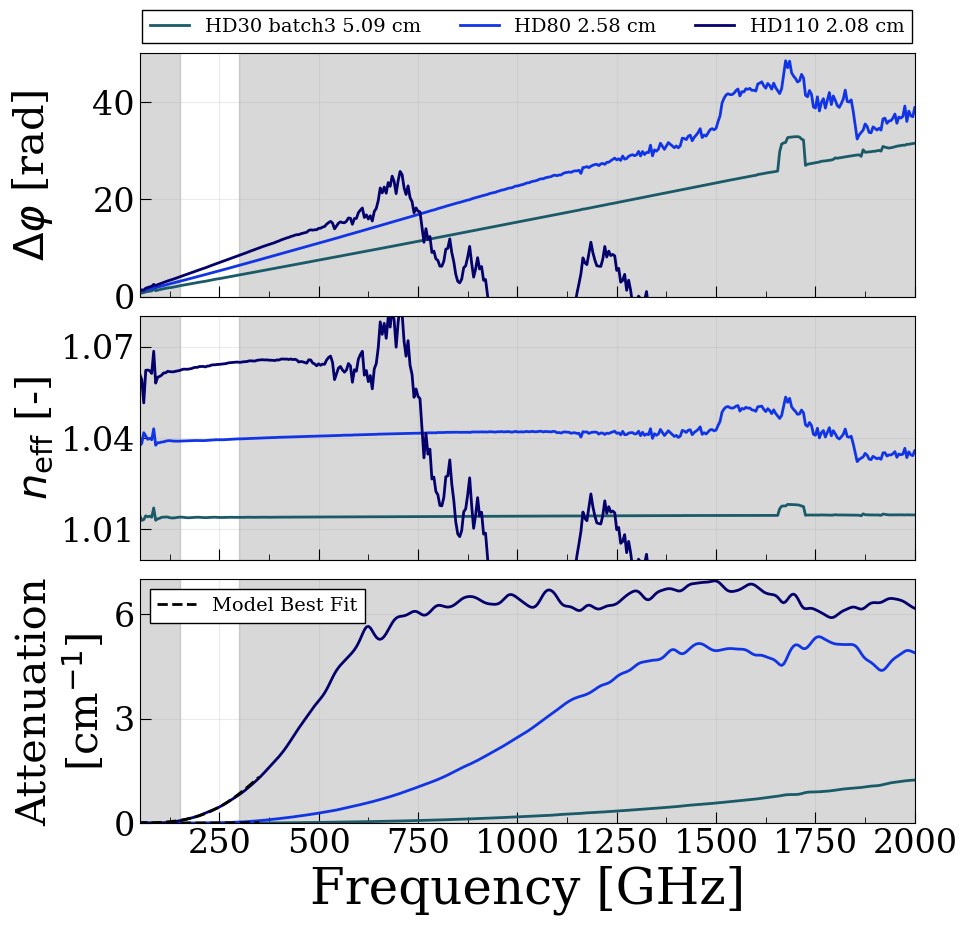

In [61]:
fig, axs = plt.subplots(
    3, 1, sharex=True, figsize=(10, 10),
    gridspec_kw=dict(height_ratios=[1, 1, 1], hspace=0.08)
)

i = 0
for bname, b in batches.items():
    for sample in b:
        if bname not in ['HD80 2.58 cm', 'HD110 2.08 cm'] and sample != 'HD30 batch3 5.09 cm':
            continue

        color = b[sample]['color']

        axs[0].plot(f_, b[sample]['phase_diff'],  color=color, lw=2)
        axs[1].plot(f_, b[sample]['n'],           color=color, lw=2)
        axs[2].plot(f_, b[sample]['alpha'],       color=color, lw=2, label=sample)
        axs[2].plot(f, comb_batches[bname]['ns_alpha'], color='k', linestyle='--', lw=2)
        i += 1

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]', fontsize=30)
axs[1].set_ylabel(r'$n_{\rm eff}$ [-]', fontsize=30)
axs[2].set_ylabel(f'Attenuation\n'+r'[cm$^{-1}$]', fontsize=30)
axs[2].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(50, 2000)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
axs[1].xaxis.set_major_locator(MultipleLocator(250))
axs[1].xaxis.set_minor_locator(MultipleLocator(125))

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue

style_handles = [Line2D([0], [0], color='k', lw=2, linestyle='--', label='Model Best Fit')]

axs[0].set_ylim(0, 50)
axs[1].set_ylim(1, 1.08)
axs[1].set_yticks([1.01, 1.04, 1.07])
axs[2].set_ylim(0, 7)
axs[2].set_yticks([0, 3, 6])
# Legend (single, clean)

handles, labels = axs[2].get_legend_handles_labels()

axs[0].legend(handles, labels, fontsize=14, loc='lower center', 
               bbox_to_anchor=(0.5, 1), ncol=3, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

axs[2].legend(handles=style_handles, fontsize=14, loc='upper left', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()

fig.align_ylabels([axs[0], axs[1]])
# plt.savefig("phase_plot-d.pdf", bbox_inches='tight', facecolor='white')
plt.show()

In [62]:
rows = []

param_names = ["Loss tangent", "C", "K_ray", "K_Mie"]

for bname, b in comb_batches.items():
    if 'HD60' in bname:
        continue
    row = {"Sample": DISPLAY_MAP[bname]}

    # Get the parameters and uncertainties from the appropriate fit

    for i, pname in enumerate(param_names):
        val = float(b['params'][i])
        up  = float(b['upper_params'][i])
        lo  = float(b['lower_params'][i])

        if pname == 'Loss tangent':
                row[pname] = format_val(val+up)
        else:
            row[pname] = format_unc(val, lo, up)

    val = b['n_eff']
    sig = b['n_eff_err']

    row["n_eff^2"] = format_unc_1sided(val, sig)

    rows.append(row)

df = pd.DataFrame(rows)

for _, row in df.iterrows():
    cells = [row["Sample"]] + [row[p] for p in param_names] + [row["n_eff^2"]]
    print(" & ".join(cells) + r" \\")

Styrofoam batch & $8.6\times10^{-5}$ & $0.10^{+0.81}_{-0.10}$ & $600^{+1000}_{-300}$ & $3000^{+1000}_{-1000}$ & $1.019(2)$ \\
LD15 batch 1 & $1.5\times10^{-5}$ & $0.02^{+0.13}_{-0.02}$ & $2000^{+2000}_{-1000}$ & $2000^{+1000}_{-1000}$ & $1.00891(1)$ \\
LD15 batch 2 & $3.1\times10^{-5}$ & $6^{+161}_{-6}\times10^{-4}$ & $2000^{+1000}_{-1000}$ & $2000^{+1000}_{-1000}$ & $1.0072(6)$ \\
LD24 batch 1 & $2.6\times10^{-6}$ & $0.003^{+0.016}_{-0.003}$ & $300^{+200}_{-100}$ & $2700^{+900}_{-1200}$ & $1.01149(2)$ \\
LD24 batch 2 & $2.7\times10^{-5}$ & $7^{+228}_{-7}\times10^{-4}$ & $2000^{+1000}_{-1000}$ & $2000^{+1000}_{-1000}$ & $1.0121(3)$ \\
HD30 batch 1 & $6.0\times10^{-6}$ & $3^{+43}_{-2}\times10^{-4}$ & $2000^{+1000}_{-1000}$ & $2000^{+1000}_{-1000}$ & $1.019(2)$ \\
HD30 batch 2 & $1.6\times10^{-5}$ & $4^{+88}_{-4}\times10^{-4}$ & $2000^{+1000}_{-1000}$ & $2000^{+1000}_{-1000}$ & $1.0136(10)$ \\
HD30 batch 3 & $6.3\times10^{-6}$ & $3^{+45}_{-2}\times10^{-4}$ & $2000^{+1000}_{-1000}$ & $200

In [63]:
bname = 'HD80 2.58 cm'

ns_params = comb_batches[bname]['params']
n_eff     = comb_batches[bname]['n_eff']
alpha16, alpha50, alpha84 = comb_batches[bname]['alpha_lower'], comb_batches[bname]['ns_alpha'], comb_batches[bname]['alpha_upper']
lt = comb_batches[bname]['lt']

idx = np.argmin(np.abs(f - 200))
print(f"Per mm\n-----")
mu = np.exp(-0.1*alpha50[idx])
low = np.exp(-0.1*alpha84[idx])
up = np.exp(-0.1*alpha16[idx])
sig = (up - low)/2
print(f"Tranmission @ 200 GHz: {mu:.6f}±{sig:.6f}")


idx = np.argmin(np.abs(f - 280))
loss = IRBF_abs(280, lt, 0.05, n_eff)
print(f"For a {w} cm filter\n-----")
print(f"loss @ 280 GHz: {loss:.5f}%")
mu = np.exp(-w * alpha50[idx])
low = np.exp(-w * alpha84[idx])
up = np.exp(-w * alpha16[idx])
sig = (up - low)/2
print(f"Tranmission @ 280 GHz: {mu:.5f}±{sig:.5f}")

Per mm
-----
Tranmission @ 200 GHz: 0.999863±0.000011
For a 5 cm filter
-----
loss @ 280 GHz: 0.00690%
Tranmission @ 280 GHz: 0.97409±0.00197


In [64]:
bname = 'Styrofoam_batch'
Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])

Scatter = Mie + Ray
Scatter_lower = np.sqrt(Mie_lower**2 + Ray_lower**2)
Scatter_upper = np.sqrt(Mie_upper**2 + Ray_upper**2)

print(f"280 GHz Scattering for {bname}: {Scatter:.5f}% +{Scatter_upper:.5f}% -{Scatter_lower:.5f}%")

bname = 'LD15 batch1 2.65 cm'
Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])

Scatter = Mie + Ray
Scatter_lower = np.sqrt(Mie_lower**2 + Ray_lower**2)
Scatter_upper = np.sqrt(Mie_upper**2 + Ray_upper**2)

print(f"280 GHz Scattering for {bname}: {Scatter:.5f}% +{Scatter_upper:.5f}% -{Scatter_lower:.5f}%")

280 GHz Scattering for Styrofoam_batch: 5.26634% +3.76436% -4.38385%
280 GHz Scattering for LD15 batch1 2.65 cm: 0.22595% +0.36276% -0.20242%


In [65]:
bname = 'Styrofoam_batch'
Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])
Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
Abs_lower, Abs, Abs_upper = float(comb_batches[bname]['band_avgs'][('280', 'Abs_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Abs')]), float(comb_batches[bname]['band_avgs'][('280', 'Abs_upper')])

## Difference
# bname2 = 'Styrofoam_batch2'
bname2 = 'HD30_batch3'
Ray_lower2, Ray2, Ray_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname2]['band_avgs'][('280', 'Ray_upper')])
Mie_lower2, Mie2, Mie_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname2]['band_avgs'][('280', 'Mie_upper')])
Abs_lower2, Abs2, Abs_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Abs_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Abs')]), float(comb_batches[bname2]['band_avgs'][('280', 'Abs_upper')])

Ray_lower_diff = np.sqrt(Ray_lower**2 + Ray_upper2**2)
Ray_diff = Ray - Ray2
Ray_upper_diff = np.sqrt(Ray_upper**2 + Ray_lower2**2)

Mie_lower_diff = np.sqrt(Mie_lower**2 + Mie_upper2**2)
Mie_diff = Mie - Mie2
Mie_upper_diff = np.sqrt(Mie_upper**2 + Mie_lower2**2)

Abs_lower_diff = np.sqrt(Abs_lower**2 + Abs_upper2**2)
Abs_diff = Abs - Abs2
Abs_upper_diff = np.sqrt(Abs_upper**2 + Abs_lower2**2)

print(f"280 GHz difference between {bname} and {bname2}:")      
print(f"Rayleigh: {Ray_diff:.2f} +{Ray_upper_diff:.2f} -{Ray_lower_diff:.2f}")
print(f"Mie: {Mie_diff:.2f} +{Mie_upper_diff:.2f} -{Mie_lower_diff:.2f}")
print(f"Sum: {(Ray_diff + Mie_diff):.2f} +{np.sqrt(Ray_upper_diff**2 + Mie_upper_diff**2):.2f} -{np.sqrt(Ray_lower_diff**2 + Mie_lower_diff**2):.2f}")
print(f"Absorption: {Abs_diff:.2f} +{Abs_upper_diff:.2f} -{Abs_lower_diff:.2f}")

280 GHz difference between Styrofoam_batch and HD30_batch3:
Rayleigh: 4.71 +2.02 -4.35
Mie: 0.56 +3.17 -0.54
Sum: 5.26 +3.76 -4.38
Absorption: 4.79 +5.04 -5.04


## Optical Loading Table

In [66]:
T_high = 273.0  # K
T_low  = 44.0   # K

# --- Layer temperatures (closed-form) ---
def T_eff_from_N_d(N, d):
    i    = np.arange(1, N+1)
    T    = (T_high**4 - i/(N+1) * (T_high**4 - T_low**4))**0.25
    T_eff = np.sum(d * T) / np.sum(d)
    return T_eff

N = 24
d = np.ones(N) * 1.5
d[0] = d[-1] = 6.0

T_eff_styro = T_eff_from_N_d(N, d)

N = 16
d = np.ones(N) * 0.3175

T_eff_zote_SAT = T_eff_from_N_d(N, d)

N = 14
d = np.ones(N) * 0.3175
d[0] = 2.54

T_eff_zote_LAT = T_eff_from_N_d(N, d)

print(f"T_eff = {T_eff_styro:.0f} K")
print(f"T_eff = {T_eff_zote_SAT:.0f} K")
print(f"T_eff = {T_eff_zote_LAT:.0f} K")

T_eff = 215 K
T_eff = 221 K
T_eff = 237 K


In [67]:
from scipy.constants import k
Tphys = 273
Npol = 1

bands = ['90', '150', '220', '280']
bandwidths = [35.0, 45.0, 45.0, 65.0]  # GHz

loading_batches = [
    ('Styrofoam', comb_batches['Styrofoam_batch']),
    ('LD15', comb_batches['LD15 batch1 2.65 cm']),
    ('LD24', comb_batches['LD24 batch1 2.60 cm']),
    ('HD30', comb_batches['HD30_batch3']),
]

for name, b in loading_batches:

    row_entries_odd = [name]
    row_entries_even = ['']

    for i, (band, dnu) in enumerate(zip(bands, bandwidths)):

        row_entries = row_entries_odd if i % 2 == 0 else row_entries_even

        Abs = float(b['band_avgs'][(band, 'Abs')]) / 100.0

        T_RJ = Tphys * Abs
        P = Npol * k * T_RJ * dnu * 1e21   # convert GHz → Hz and Watts → pW

        if name in ['Thin Sheets 1 (Worst)', 'Thick Sheets 2 (Best)', 'Representative Filter']:
            Abs_lower = float(b['band_avgs'][(band, 'Abs_lower')]) / 100.0
            Abs_upper = float(b['band_avgs'][(band, 'Abs_upper')]) / 100.0  
            T_RJ_lower = Tphys * Abs_lower
            T_RJ_upper = Tphys * Abs_upper
            P_lower = Npol * k * T_RJ_lower * dnu * 1e21
            P_upper = Npol * k * T_RJ_upper * dnu * 1e21

            row_entries.extend([
                format_unc(Abs, Abs_lower, Abs_upper, sci_thresh=0.01),
                format_unc(T_RJ, T_RJ_lower, T_RJ_upper, sci_thresh=0.01),
                format_unc(P, P_lower, P_upper, sci_thresh=0.01),
            ])
                
        elif name in ['LD15', 'LD24', 'HD30']:
            row_entries.extend([
                format_val(Abs),
                format_val(T_RJ),
                format_val(P)
            ])

        else:
            row_entries.extend([
                f"{Abs:.4f}",
                f"{T_RJ:.2f}",
                f"{P:.2f}"
            ])

    print(" & ".join(row_entries_odd) + r" \\")
    print(" & ".join(row_entries_even) + r" \\[6pt]")

Styrofoam & 0.0168 & 4.58 & 2.21 & 0.0403 & 11.01 & 6.84 \\
 & 0.0257 & 7.03 & 4.37 & 0.0504 & 13.75 & 12.34 \\[6pt]
LD15 & $4.4\times10^{-4}$ & $0.12$ & $0.06$ & $1.1\times10^{-3}$ & $0.29$ & $0.18$ \\
 & $6.7\times10^{-4}$ & $0.18$ & $0.11$ & $1.3\times10^{-3}$ & $0.36$ & $0.33$ \\[6pt]
LD24 & $7.2\times10^{-4}$ & $0.20$ & $0.10$ & $1.8\times10^{-3}$ & $0.48$ & $0.30$ \\
 & $1.1\times10^{-3}$ & $0.30$ & $0.19$ & $2.2\times10^{-3}$ & $0.60$ & $0.54$ \\[6pt]
HD30 & $8.2\times10^{-4}$ & $0.22$ & $0.11$ & $2.0\times10^{-3}$ & $0.55$ & $0.34$ \\
 & $1.3\times10^{-3}$ & $0.35$ & $0.22$ & $2.5\times10^{-3}$ & $0.69$ & $0.62$ \\[6pt]


In [68]:
rows = []

param_names = ["Loss tangent", "C", "K_ray", "K_Mie"]

for bname, b in comb_batches.items():
    T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']

    row = {"Sample": bname}

    # --- parameters with uncertainties ---
    for i, pname in enumerate(param_names):
        val = float(b['params'][i])
        up  = float(b['upper_params'][i])
        lo  = float(b['lower_params'][i])

        row[pname] = format_unc(val, lo, up)

    row["n_eff^2"] = rf"${b['n_eff']:.3f} \pm {b['n_eff_err']:.4f}$"

    # --- band-averaged transmittance ---
    for band_name, (lo_f, hi_f) in band_windows.items():
        sel = (f > lo_f) & (f < hi_f)

        val       = 100*float(np.mean(ns_T[sel]))
        upper_val = 100*float(np.mean(T_upper[sel]))
        lower_val = 100*float(np.mean(T_lower[sel]))

        up = upper_val - val
        lo = val - lower_val

        # row[f"T{band_name} [%]"] = format_unc(val, lo, up)

    rows.append(row)

df = pd.DataFrame(rows)
df


,Sample,Loss tangent,C,K_ray,K_Mie,n_eff^2
0,Styrofoam_batch,$4^{+5}_{-3}\times10^{-5}$,$0.10^{+0.81}_{-0.10}$,$600^{+1000}_{-300}$,$3000^{+1000}_{-1000}$,$1.019 \pm 0.0024$
1,LD15 batch1 2.65 cm,$9^{+6}_{-6}\times10^{-6}$,$0.02^{+0.13}_{-0.02}$,$2000^{+2000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.009 \pm 0.0000$
2,LD15_batch2,$2^{+1}_{-1}\times10^{-5}$,$6^{+161}_{-6}\times10^{-4}$,$2000^{+1000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.007 \pm 0.0006$
3,LD24 batch1 2.60 cm,$1.0^{+1.6}_{-0.8}\times10^{-6}$,$0.003^{+0.016}_{-0.003}$,$300^{+200}_{-100}$,$2700^{+900}_{-1200}$,$1.011 \pm 0.0000$
4,LD24_batch2,$2.1^{+0.6}_{-0.7}\times10^{-5}$,$7^{+228}_{-7}\times10^{-4}$,$2000^{+1000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.012 \pm 0.0003$
5,HD30_batch1,$2^{+4}_{-2}\times10^{-6}$,$3^{+43}_{-2}\times10^{-4}$,$2000^{+1000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.019 \pm 0.0023$
6,HD30_batch2,$6^{+9}_{-5}\times10^{-6}$,$4^{+88}_{-4}\times10^{-4}$,$2000^{+1000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.014 \pm 0.0010$
7,HD30_batch3,$2^{+4}_{-2}\times10^{-6}$,$3^{+45}_{-2}\times10^{-4}$,$2000^{+1000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.014 \pm 0.0004$
8,PP35 0.32 cm,$5^{+6}_{-3}\times10^{-6}$,$4^{+85}_{-4}\times10^{-4}$,$2000^{+1000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.018 \pm 0.0001$
9,HD80 2.58 cm,$8^{+14}_{-6}\times10^{-8}$,$7^{+21}_{-5}\times10^{-4}$,$170^{+70}_{-50}$,$3200^{+600}_{-900}$,$1.039 \pm 0.0002$


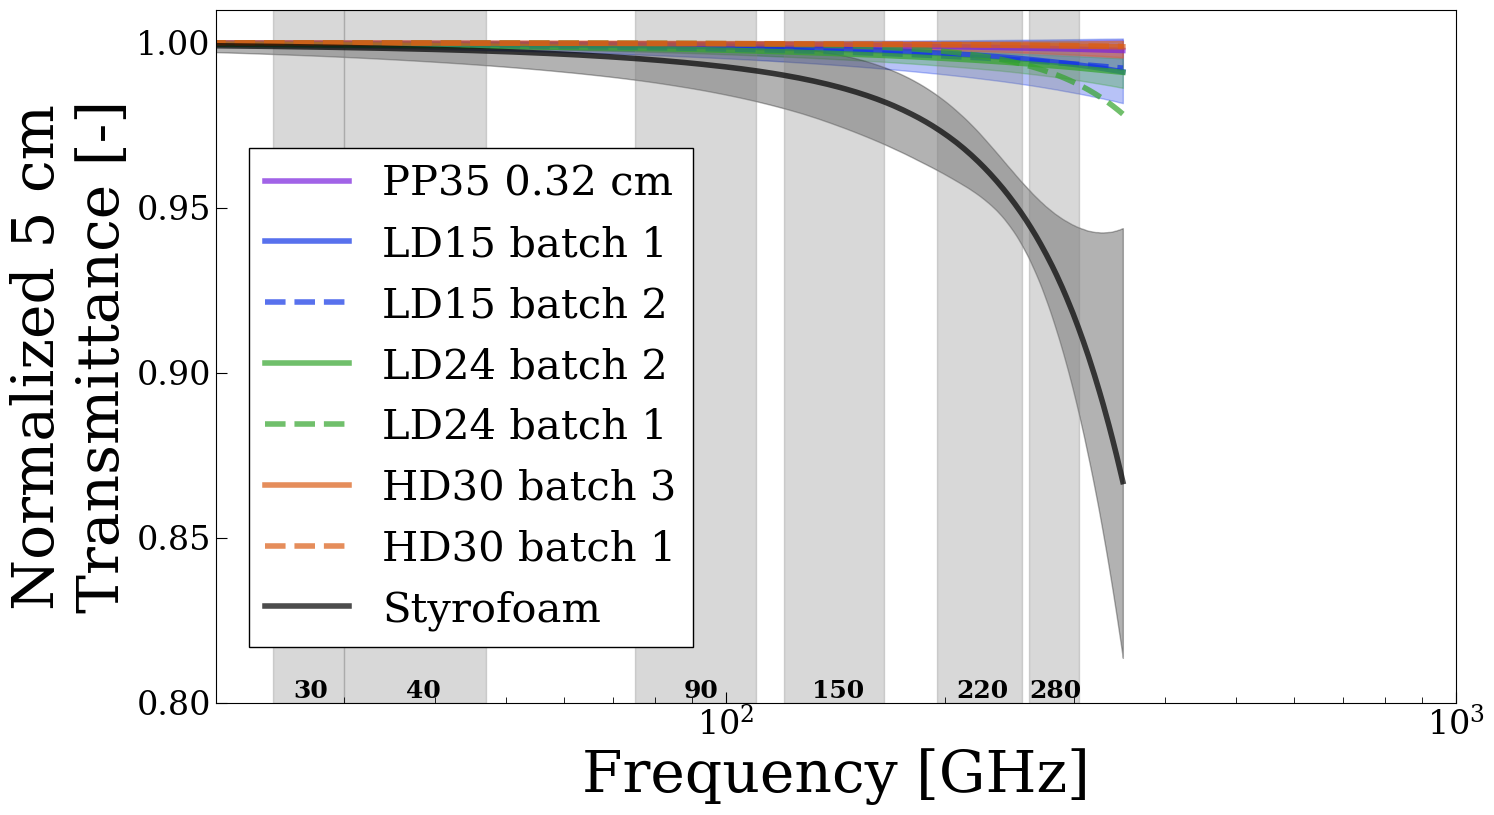

In [69]:
from matplotlib.ticker import NullFormatter

DISPLAY_MAP2 = {
    "PP35 0.32 cm": ["PP35 0.32 cm", comb_batches['PP35 0.32 cm']['color'], '-'],
    "LD15 batch1 2.65 cm": ["LD15 batch 1", colors2[4], '-'],
    "LD15_batch2": ["LD15 batch 2", colors2[4], '--'],
    "LD24_batch2": ["LD24 batch 2", colors2[3], '-'],
    "LD24 batch1 2.60 cm": ["LD24 batch 1", colors2[3], '--'],
    "HD30_batch3": ["HD30 batch 3", comb_batches['HD30_batch2']['color'], '-'],
    "HD30_batch1": ["HD30 batch 1", comb_batches['HD30_batch2']['color'], '--'],
    "Styrofoam_batch": ["Styrofoam", 'k', '-'],
}

fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Plot measurements and fits
for bname in DISPLAY_MAP2.keys():
    b = comb_batches[bname]
    label, color, ls = DISPLAY_MAP2[bname]

    ns_T = b['ns_T_5cm']
    ns_T_upper = b['T_upper_5cm']
    ns_T_lower = b['T_lower_5cm']

    ns_T_upper2 = 2*ns_T_upper - ns_T
    ns_T_lower2 = 2*ns_T_lower - ns_T

    if bname not in ['LD15 batch1 2.65 cm', 'LD24 batch1 2.60 cm']:
        plt.fill_between(f, ns_T_lower2, ns_T_upper2, color=color, alpha=0.3)

    plt.plot(f, ns_T, color=color, lw=4, label=label, linestyle=ls, alpha=0.7)

xticks = []
for band, (i, j) in band_windows.items():
    plt.axvspan(i, j, color='gray', alpha=0.3)
    plt.text((i+j)/2, 0.80, band, horizontalalignment='center', verticalalignment='bottom', fontsize=18, color='black', fontweight='bold')

ax.legend(loc='lower left', bbox_to_anchor=(0.01, 0.05), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

plt.xlim(20, 1000)
ax.yaxis.set_major_locator(MultipleLocator(0.05))
plt.ylim(0.8, 1.01)
plt.xscale('log')
ax.xaxis.set_minor_formatter(NullFormatter())

plt.xlabel('Frequency [GHz]', fontsize=42)
plt.ylabel('Normalized 5 cm\nTransmittance [-]', fontsize=42)
plt.gcf().set_facecolor('white')
plt.savefig('5cm_spectra-d.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [70]:
rows = []

header = ["Sample"] + [f"T{band} [%]" for band in band_windows.keys()]

rows.append(dict(zip(header, header)))

for bname, b in list(comb_batches.items()):
    if bname not in ['Styrofoam_batch', 'LD15 batch1 2.65 cm', 'LD15 batch2 0.30 cm', 'LD24 batch1 2.60 cm', 'LD24 batch2 0.34 cm', 'HD30_batch1', 'HD30_batch2', 'HD30_batch3', 'HD80 2.58 cm', 'HD110 2.08 cm']:
        continue

    row = {"Sample": bname}
    
    T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']

    # --- band-averaged transmittance ---
    for band_name, (lo_f, hi_f) in band_windows.items():
        sel = (f > lo_f) & (f < hi_f)

        val = 100*float(np.mean(ns_T[sel]))
        upper_val = 100*float(np.mean(T_upper[sel]))
        lower_val = 100*float(np.mean(T_lower[sel]))

        up = upper_val - val
        lo = val - lower_val

        row[f"T{band_name} [%]"] = format_unc(val, lo, up)

    rows.append(row)

df = pd.DataFrame(rows)

for _, row in df.iterrows():
    cells = [row["Sample"]] + [row[f"T{band} [%]"] for band in band_windows.keys()]
    print(" & ".join(cells) + r" \\")

Sample & T30 [%] & T40 [%] & T90 [%] & T150 [%] & T220 [%] & T280 [%] \\
Styrofoam_batch & $99.87^{+0.08}_{-0.13}$ & $99.8^{+0.1}_{-0.2}$ & $99.3^{+0.3}_{-0.4}$ & $98.6^{+0.5}_{-0.6}$ & $96.2^{+0.5}_{-0.5}$ & $93.0^{+0.9}_{-0.8}$ \\
LD15 batch1 2.65 cm & $99.97^{+0.01}_{-0.02}$ & $99.96^{+0.02}_{-0.02}$ & $99.89^{+0.03}_{-0.04}$ & $99.81^{+0.03}_{-0.04}$ & $99.60^{+0.02}_{-0.02}$ & $99.41^{+0.08}_{-0.06}$ \\
LD24 batch1 2.60 cm & $99.997^{+0.002}_{-0.004}$ & $99.995^{+0.003}_{-0.006}$ & $99.975^{+0.008}_{-0.015}$ & $99.91^{+0.01}_{-0.02}$ & $99.58^{+0.04}_{-0.04}$ & $99.03^{+0.10}_{-0.10}$ \\
HD30_batch1 & $99.993^{+0.005}_{-0.011}$ & $99.990^{+0.007}_{-0.015}$ & $99.98^{+0.02}_{-0.04}$ & $99.96^{+0.03}_{-0.06}$ & $99.94^{+0.05}_{-0.09}$ & $99.91^{+0.06}_{-0.12}$ \\
HD30_batch2 & $99.98^{+0.01}_{-0.03}$ & $99.97^{+0.02}_{-0.04}$ & $99.93^{+0.05}_{-0.09}$ & $99.89^{+0.08}_{-0.14}$ & $99.8^{+0.1}_{-0.2}$ & $99.8^{+0.2}_{-0.3}$ \\
HD30_batch3 & $99.993^{+0.005}_{-0.011}$ & $99.989^{+0.008

# Estimating Cell Sizes

In [71]:
comb_batches['LD15 batch1 2.65 cm']['cell_size'] = 380e-6
comb_batches['LD15_batch2']['cell_size'] = 380e-6
comb_batches['LD24 batch1 2.60 cm']['cell_size'] = 300e-6
comb_batches['LD24_batch2']['cell_size'] = 300e-6
comb_batches['HD30_batch1']['cell_size']  = 400e-6
comb_batches['HD30_batch2']['cell_size']  = 400e-6
comb_batches['HD30_batch3']['cell_size']  = 400e-6
# comb_batches['HD60 2.03 cm']['cell_size'] = 400e-6
comb_batches['HD80 2.58 cm']['cell_size'] = 600e-6
comb_batches['HD110 2.08 cm']['cell_size'] = 1050e-6

rows = []

def _cm_factor(n_p):
    np2 = n_p**2
    return np.abs((np2 + 2)*(1 + 2*np2) - 2*(np2 - 1)**2) / np.abs((1 + 2*np2)*(np2 - 1))

def eff_cell_diameter(K_Mie_GHz, K_Ray_GHz, n_p=1.54, n_m=1.0003, c=3e8):
    m   = n_p / n_m
    return c * (m - 1) * K_Mie_GHz*1e9 / (n_m * np.pi * np.sqrt(6) * (K_Ray_GHz*1e9)**2) * _cm_factor(n_p)

def eff_wall_thickness(K_Mie_GHz, d, C, f_m, n_p=1.54, n_m=1.0003, c=3e8):
    m   = n_p / n_m
    C_m = C * 100
    return c / (2 * n_m * np.pi * (m - 1) * K_Mie_GHz*1e9) * np.sqrt(C_m * d / (6 * f_m))

def wall_thickness(d, f_m):
    return d/2 * (1 - f_m**(1/3))

for bname, b in comb_batches.items():
    if 'HD' not in bname and 'LD' not in bname:
        continue

    density = b['density']
    rho_p = b['rho_p']
    n_p   = b['n_p']
    f_p   = b['f_p']

    C     = b['params'][1]
    K_Ray = b['params'][2]
    K_Mie = b['params'][3]

    d_inv = eff_cell_diameter(K_Mie, K_Ray, n_p=n_p)

    f_m = 1 - f_p
    ell   = eff_wall_thickness(K_Mie, d_inv, C, f_m, n_p=n_p)
    l_th  = wall_thickness(b['cell_size'], f_m)

    rows.append({
        "sample":           bname,
        "density [kg/m^3]": b["density"],
        "d_th [um]":        f"{b['cell_size'] * 1e6:.2f}",
        "ell_th [um]":      f"{l_th * 1e6:.2f}",
        "ell_th/d_th":      f"{l_th / (b['cell_size']):.2e}",
        "d [um]":           f"{d_inv * 1e6:.2f}",
        "ell [um]":         f"{ell * 1e6:.2f}",
        "ell/d":            f"{ell / d_inv:.2e}",
    })

df = pd.DataFrame(rows).set_index("sample").sort_values("density [kg/m^3]")
df

,density [kg/m^3],d_th [um],ell_th [um],ell_th/d_th,d [um],ell [um],ell/d
sample,,,,,,,
LD15 batch1 2.65 cm,15.0,380.00,0.95,2.49e-03,50.48,0.18,3.47e-03
LD15_batch2,15.0,380.00,0.95,2.49e-03,27.48,0.02,7.90e-04
LD24 batch1 2.60 cm,24.0,300.00,1.24,4.14e-03,1571.66,0.30,1.88e-04
LD24_batch2,24.0,300.00,1.24,4.14e-03,26.40,0.02,9.07e-04
HD30_batch1,30.0,400.00,2.04,5.10e-03,26.70,0.01,4.96e-04
HD30_batch2,30.0,400.00,2.04,5.10e-03,26.70,0.02,6.42e-04
HD30_batch3,30.0,400.00,2.04,5.10e-03,26.75,0.01,5.08e-04
HD80 2.58 cm,80.0,600.00,8.54,1.42e-02,6474.17,0.25,3.81e-05
HD110 2.08 cm,110.0,1050.00,20.88,1.99e-02,1314.89,7.26,5.52e-03


# Custom loss plots

Secondary scattering matters for HD110 in band, matters for HD80 after ~300 GHz.

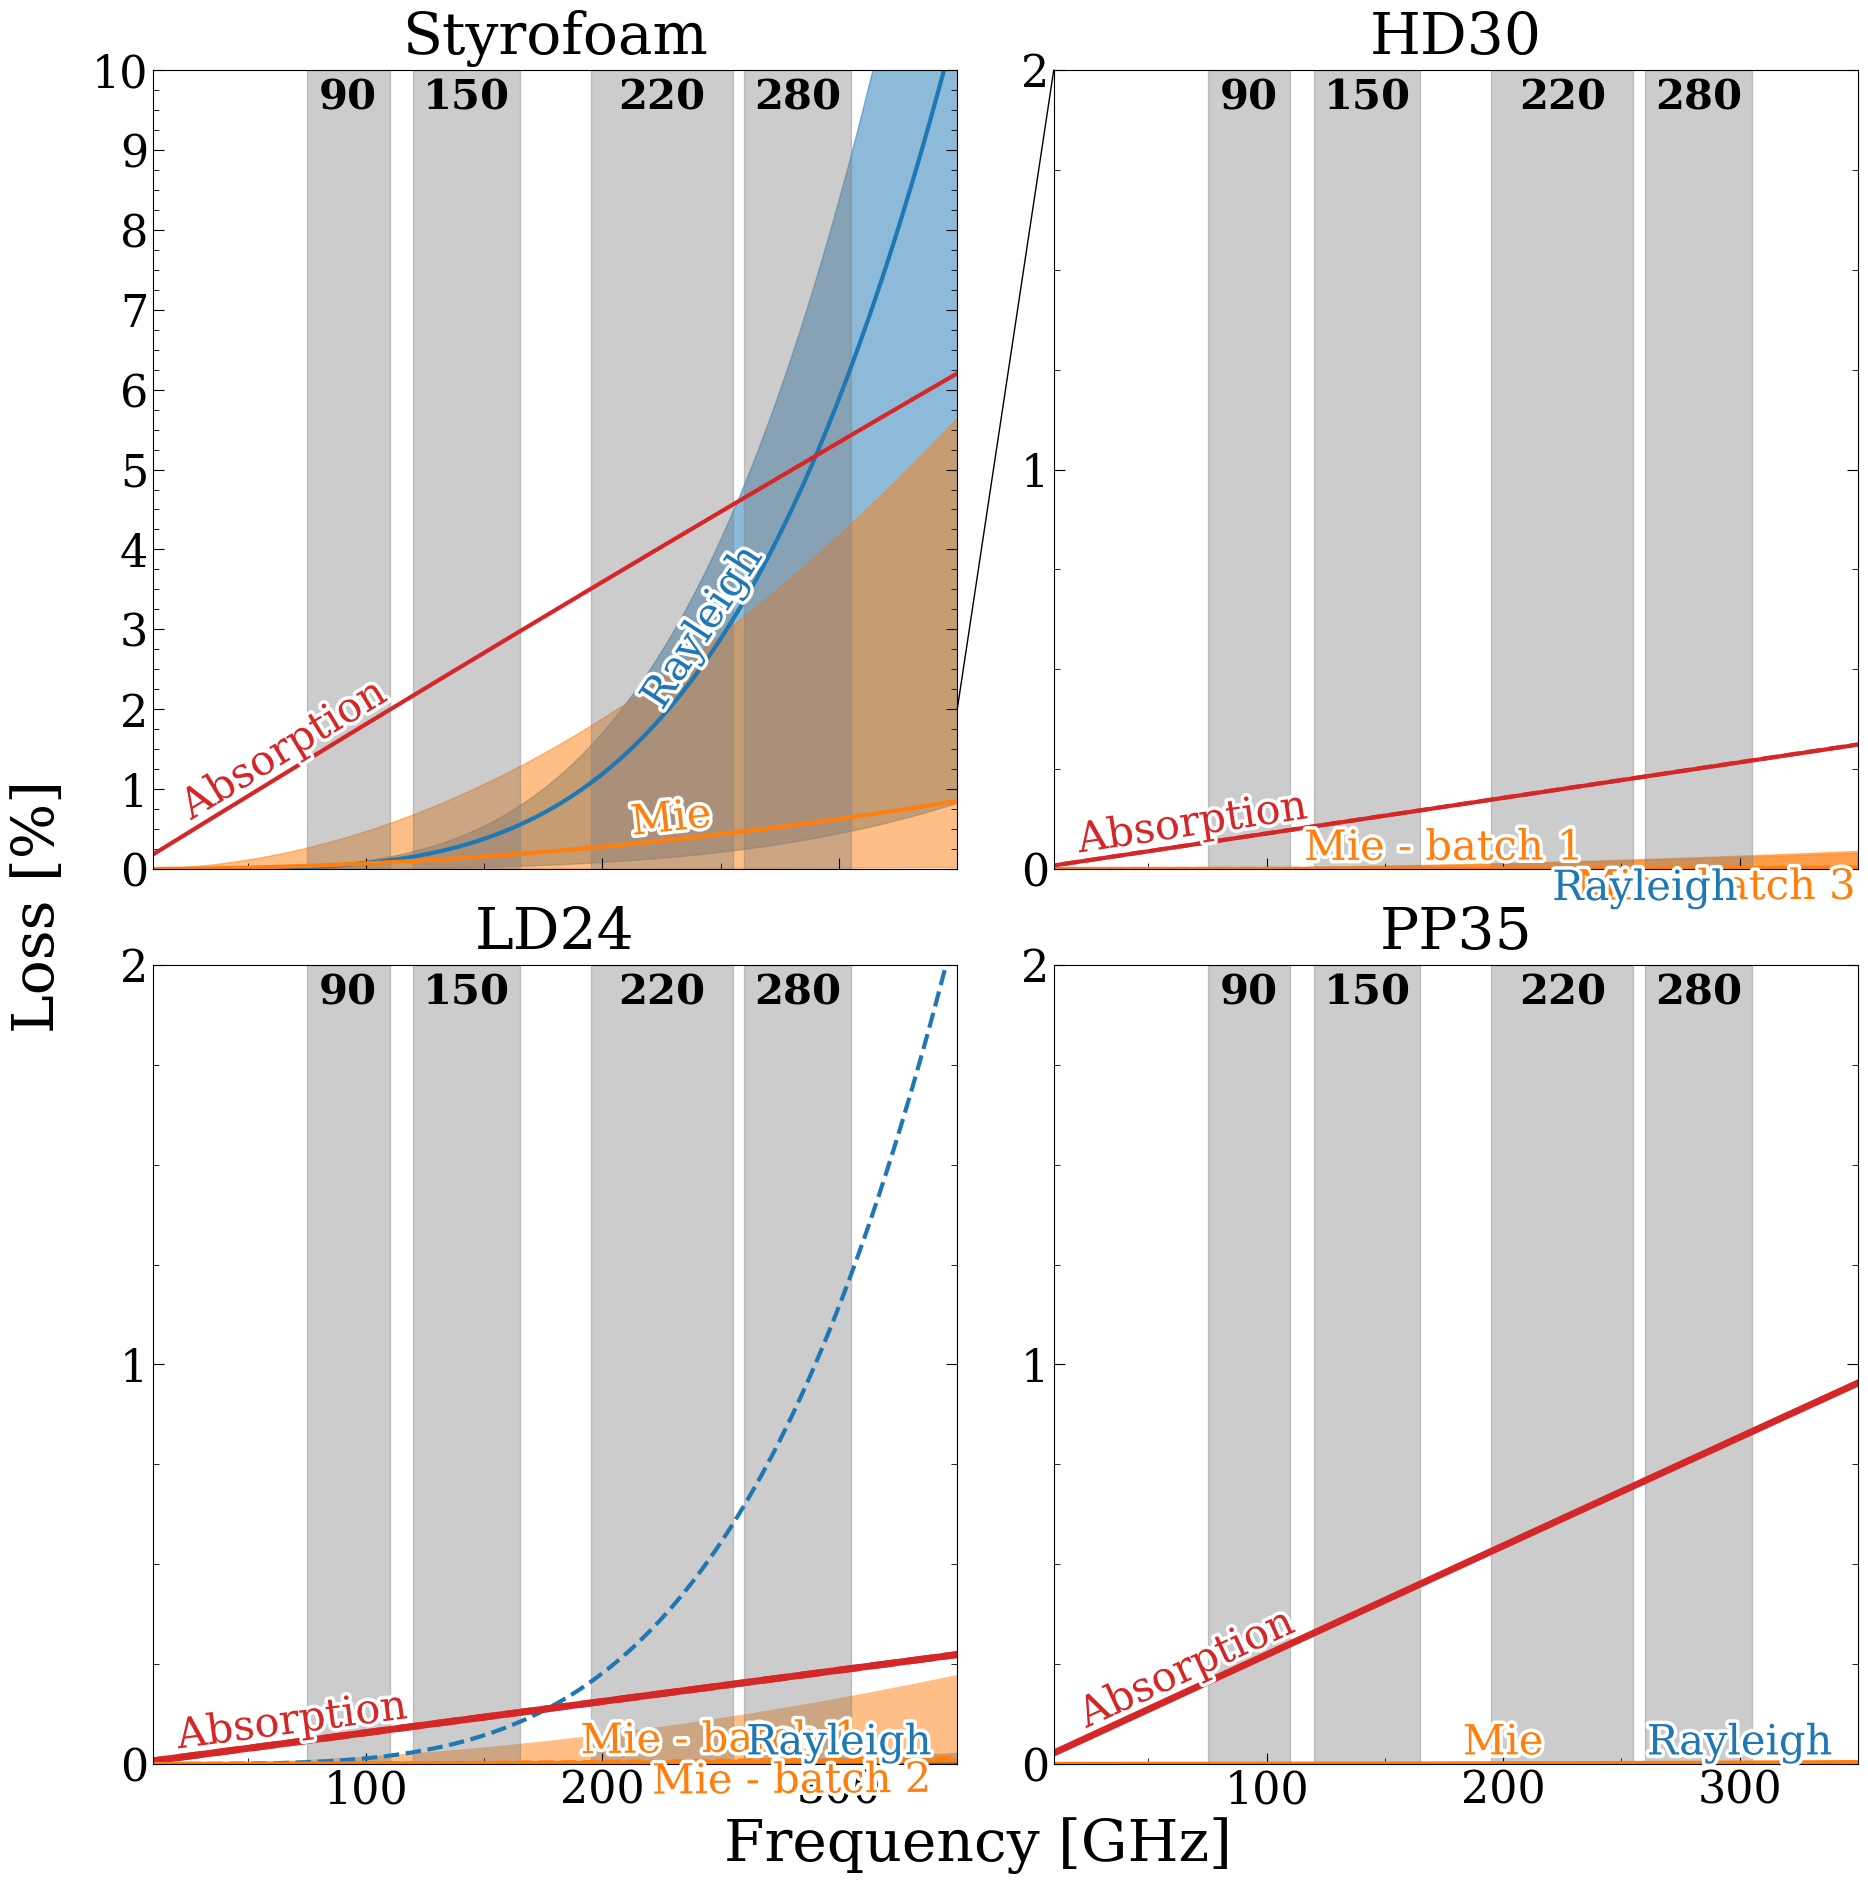

In [72]:
from matplotlib.patches import ConnectionPatch

fig, axes = plt.subplots(2, 2, figsize=(22, 22), sharex=True)
ax0, ax1, ax2, ax3 = axes.flatten()

for ax in axes.flatten():
    ax.set_rasterization_zorder(1)

## Styrofoam Batches

bname = 'Styrofoam_batch'
b = comb_batches[bname]

ax0.set_xlim(10, 350)
ax0.set_ylim(0, 10)

Abs, Abs_upper, Abs_lower, Abs_color, _ = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, _ = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, _ = b["estimates"]["Mie"].values()

ax0.plot(f, Ray, color=Ray_color, lw=3,  zorder=2)
ax0.plot(f, Mie, color=Mie_color, lw=3, zorder=2)
ax0.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
ax0.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

ax0.plot(f, Abs, color=Abs_color, lw=3, zorder=2)

fig.canvas.draw()
for freq, arr, label, color in [
    (230, Mie, 'Mie', Mie_color),
    (250, Ray, 'Rayleigh', Ray_color),
    (70, Abs,  'Absorption', Abs_color)
]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax0.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax0.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax0.text(f[idx], arr[idx], label, color=color, fontsize=30,
                ha='center', va='bottom', rotation=angle, rotation_mode='anchor')

ax0.set_title('Styrofoam', y=1.01, fontsize=42)

## HD30 Batches
j = 0
linestyles = ['--', '-']

for bname, b in comb_batches.items():
    if bname not in ['HD30_batch1', 'HD30_batch3']:
        continue
    batch_num = bname.split('_')[-1][-1]

    ax1.set_xlim(10, 350)
    ax1.set_ylim(0, 2)

    Abs, Abs_upper, Abs_lower, Abs_color, _ = b["estimates"]["Abs"].values()
    Ray, Ray_upper, Ray_lower, Ray_color, _ = b["estimates"]["Ray"].values()
    Mie, Mie_upper, Mie_lower, Mie_color, _ = b["estimates"]["Mie"].values()

    ax1.plot(f, Ray, color=Ray_color, lw=3, ls=linestyles[j], zorder=2)
    ax1.plot(f, Mie, color=Mie_color, lw=3, ls=linestyles[j], zorder=2)
    ax1.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
    ax1.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

    ax1.plot(f, Abs, color=Abs_color, lw=3, ls=linestyles[j], zorder=2)

    fig.canvas.draw()

    if j == 1:
        idx = np.argmin(np.abs(f - 290))
        p0 = ax1.transData.transform((f[idx-10], Mie[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Mie[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Mie[idx], f"Mie - batch {batch_num}", color=Mie_color, fontsize=30,
                ha='center', va='top', rotation=angle, rotation_mode='anchor')
        
        idx = np.argmin(np.abs(f - 260))
        p0 = ax1.transData.transform((f[idx-10], Ray[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Ray[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Ray[idx], "Rayleigh", color=Ray_color, fontsize=30,
                 ha='center', va='top', rotation=angle, rotation_mode='anchor')
        
    else:
        idx = np.argmin(np.abs(f - 70))
        p0 = ax1.transData.transform((f[idx-10], Abs[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Abs[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Abs[idx], 'Absorption', color=Abs_color, fontsize=30,
                 ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
        
        idx = np.argmin(np.abs(f - 175))
        p0 = ax1.transData.transform((f[idx-10], Mie[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Mie[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Mie[idx], f"Mie - batch {batch_num}", color=Mie_color, fontsize=30,
             ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
        
    j += 1

ax1.set_title('HD30', y=1.01, fontsize=42)

## LD24
bname = 'LD24 batch1 2.60 cm'
b = comb_batches[bname]
display_name = DISPLAY_MAP.get(bname, bname)

ax2.set_xlim(10, 350)
ax2.set_ylim(0, 2)

Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

ax2.plot(f, Abs, color=Abs_color, lw=5, linestyle=linestyles[0], zorder=2)
ax2.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[0], zorder=2)
ax2.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[0], zorder=2)
# ax2.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
# ax2.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

fig.canvas.draw()
for freq, arr, label, color, fs, va in [
    (250, Mie, 'Mie - batch 1',       Mie_color, 30, 'bottom'),
]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax2.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax2.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax2.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor')

ax2.set_title(bname.split()[0], y=1.01, fontsize=42)

bname = 'LD24_batch2'
b = comb_batches[bname]
display_name = DISPLAY_MAP.get(bname, bname)

Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

ax2.plot(f, Abs, color=Abs_color, lw=5, linestyle=linestyles[1], zorder=2)
ax2.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[1], zorder=2)
ax2.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[1], zorder=2)
ax2.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
ax2.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

fig.canvas.draw()
for freq, arr, label, color, fs, va in [
    (280, Mie, 'Mie - batch 2', Mie_color, 30, 'top'),
    (70, Abs, 'Absorption', Abs_color, 30, 'bottom'),
    (300, Ray, 'Rayleigh',  Ray_color, 30, 'bottom'),
    ]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax2.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax2.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax2.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor')

## PP35
bname = 'PP35 0.32 cm'
b = comb_batches[bname]

ax3.set_xlim(10, 350)
ax3.set_ylim(0, 2)

Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

ax3.plot(f, Abs, color=Abs_color, lw=5, linestyle=linestyles[1], zorder=2)
ax3.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[1], zorder=2)
ax3.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[1], zorder=2)
# ax3.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
# ax3.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

fig.canvas.draw()
for freq, arr, label, color, fs, va in [
    (70, Abs,  'Absorption', Abs_color, 30, 'bottom'),
    (300, Ray, 'Rayleigh',            Ray_color, 30, 'bottom'),
    (200, Mie, 'Mie', Mie_color, 30, 'bottom'),
]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax3.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax3.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax3.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor', zorder=10)

ax3.set_title(bname.split(' ')[0], y=1.01, fontsize=42)

## General
for ax in axes.flatten():
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.25))
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.xaxis.set_minor_locator(MultipleLocator(50))
    ax.tick_params(axis='both', which='major', labelsize=32)
    ax.tick_params(axis='y', which='both', left=True, right=True)
    for band, (lbound, ubound) in band_windows.items():
        if band not in ["90", "150", "220", "280"]:
            continue
        band_center = (lbound + ubound) / 2
        ax.text(band_center, 0.99*ax.get_ylim()[1], band, color='k', ha='center', va='top', fontsize=30, fontweight='bold')
        ax.axvspan(lbound, ubound, alpha=0.4, color='gray', zorder=0)

fig.supxlabel('Frequency [GHz]', fontsize=42, y=0.06)
fig.supylabel('Loss [%]', fontsize=42, x=0.06)
plt.subplots_adjust(hspace=0.12, wspace=0.12)

con = ConnectionPatch(
    xyA=(0, 2), coordsA=ax1.get_yaxis_transform(),
    xyB=(1, 2), coordsB=ax0.get_yaxis_transform(),
    color="k", linewidth=1
)
fig.add_artist(con)

for ax in axes.flatten():
    for txt in ax.texts:
        if mcolors.to_rgb(txt.get_color()) == (0.0, 0.0, 0.0):
            continue
        txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])

plt.gcf().set_facecolor('white')
plt.savefig('components-d.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [73]:
Ray1 = next(iter(comb_batches['HD30_batch1']["estimates"]["Ray"].values()))
Ray2 = next(iter(comb_batches['HD30_batch2']["estimates"]["Ray"].values()))
Ray3 = next(iter(comb_batches['HD30_batch3']["estimates"]["Ray"].values()))

Mie1 = next(iter(comb_batches['HD30_batch1']["estimates"]["Mie"].values()))
Mie2 = next(iter(comb_batches['HD30_batch2']["estimates"]["Mie"].values()))
Mie3 = next(iter(comb_batches['HD30_batch3']["estimates"]["Mie"].values()))

Rays = np.array([Ray1, Ray2, Ray3])
Mies = np.array([Mie1, Mie2, Mie3])

idx = np.argmin(np.abs(f - 280))
min_key = np.argmin(Rays[:, idx])
max_key = np.argmax(Rays[:, idx])

min_sigma = (comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Ray"]['upper'][idx] - comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Ray"]['lower'][idx]) / 2
max_sigma = (comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Ray"]['upper'][idx] - comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Ray"]['lower'][idx]) / 2

print(f"At 280 GHz, min Rayleigh is Batch {min_key+1} with value {Rays[min_key, idx]:.4f} ± {min_sigma:.4f}, max Rayleigh is Batch {max_key+1} with value {Rays[max_key, idx]:.4f} ± {max_sigma:.4f}, difference: {(Rays[max_key, idx] - Rays[min_key, idx]):.4f} ± {(min_sigma**2 + max_sigma**2)**0.5:.4f}")
      
min_key = np.argmin(Mies[:, idx])
max_key = np.argmax(Mies[:, idx])

min_sigma = (comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Mie"]['upper'][idx] - comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Mie"]['lower'][idx]) / 2
max_sigma = (comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Mie"]['upper'][idx] - comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Mie"]['lower'][idx]) / 2

print(f"At 280 GHz, min Mie is Batch {min_key+1} with value {Mies[min_key, idx]:.4f} ± {min_sigma:.4f}, max Mie is Batch {max_key+1} with value {Mies[max_key, idx]:.4f} ± {max_sigma:.4f}, difference: {(Mies[max_key, idx] - Mies[min_key, idx]):.4f} ± {(min_sigma**2 + max_sigma**2)**0.5:.4f}")

At 280 GHz, min Rayleigh is Batch 3 with value 0.0001 ± 0.0014, max Rayleigh is Batch 2 with value 0.0001 ± 0.0027, difference: 0.0000 ± 0.0030
At 280 GHz, min Mie is Batch 3 with value 0.0020 ± 0.0131, max Mie is Batch 2 with value 0.0031 ± 0.0265, difference: 0.0011 ± 0.0296


In [74]:
# =============================================================================
# Excess optical loading from 273 K blackbody scattered into 40-90 deg
# =============================================================================
# The scattering fractions Ray(f) and Mie(f) [in %] give what fraction of the
# beam is redirected per unit path by Rayleigh / Mie scattering.  The phase
# function P(theta) tells us what fraction of that scattered power lands in a
# given solid-angle wedge.  We integrate P from 40 to 90 deg to get F_Ray and
# F_Mie(f) -- the fraction heading into the warm (273 K) environment.
# Loading per band:  P = k * T_bb * <scatter_frac * F_angular> * delta_nu
# =============================================================================

from scipy.special import spherical_jn as _sjn

# Riccati-Bessel functions
def _psi(n, x):       return x * _sjn(n, x)
def _psi_p(n, x):     return _sjn(n, x) + x * _sjn(n, x, derivative=True)

# Thin-shell Mie Coefficients
def _ab_shell(n, m, x, delta):
    p, pp = _psi(n, x), _psi_p(n, x)
    bn = -1j * delta * (m**2 - 1) * p**2
    an = -1j * delta * (n*(n+1)*(m**2-1)/(m**2*x**2) * p**2 + (m**2-1)*pp**2)
    return an, bn

# Pi and Tau
def _pi_tau(nmax, tr):
    ct = np.cos(tr)
    PA, TA = np.zeros((nmax, len(tr))), np.zeros((nmax, len(tr)))
    pp, p  = np.zeros(len(tr)), np.ones(len(tr))
    for n in range(1, nmax+1):
        TA[n-1] = n*ct*p - (n+1)*pp;  PA[n-1] = p
        pp, p   = p, ((2*n+1)*ct*p - (n+1)*pp) / n
    return PA, TA

# Phase function for thin-shell Mie scattering
def _phase(al, bl, tr):
    PA, TA = _pi_tau(len(al), tr)
    S1 = np.zeros(len(tr), dtype=complex)
    S2 = np.zeros(len(tr), dtype=complex)
    for n, (a, b) in enumerate(zip(al, bl), 1):
        fac = (2*n+1)/(n*(n+1))
        S1 += fac*(a*PA[n-1]+b*TA[n-1])
        S2 += fac*(b*PA[n-1]+a*TA[n-1])
    P = (np.abs(S1)**2 + np.abs(S2)**2) / 2
    return P / (np.trapezoid(P*np.sin(tr), tr) * 2*np.pi)  # int_4pi = 1

# ---- Angular grid ----------------------------------------------------------
th_deg = np.linspace(0, 180, 181)
th_rad = np.deg2rad(th_deg)
th_rad[0] = 1e-6;  th_rad[-1] = np.pi - 1e-6
m40_90 = (th_deg >= 40) & (th_deg <= 90)   # mask: warm-environment wedge

# ---- Rayleigh fraction in 40-90 deg (frequency-independent) ---------------
P_ray = (3/(16*np.pi)) * (1 + np.cos(th_rad)**2)
F_Ray = 2*np.pi * np.trapezoid(P_ray[m40_90]*np.sin(th_rad[m40_90]), th_rad[m40_90])
print(f'Rayleigh fraction in 40-90 deg: {100*F_Ray:.1f}% of scattered power')

# ---- Thin-shell Mie fraction in 40-90 deg, vs frequency -------------------
c_mie   = 30.0    # GHz*cm
m_mie   = 1.54    # n_p / n_m  (n_m=1, n_p=1.54)
d_mie   = 400e-4  # cm  (400 um cell diameter)
ell_mie = 2e-4    # cm  (2 um wall thickness)
N_mul   = 30

# Compute on a coarse 10-GHz grid, then interpolate to the 1-GHz f array
F_Mie = np.empty(len(f))
for _i, _f in enumerate(f):
    _x  = np.pi * d_mie * _f / c_mie
    _dlt = np.pi * ell_mie * _f / c_mie
    _al, _bl = zip(*[_ab_shell(_n, m_mie, _x, _dlt) for _n in range(1, N_mul+1)])
    _P = _phase(list(_al), list(_bl), th_rad)
    F_Mie[_i] = 2*np.pi * np.trapezoid(_P[m40_90]*np.sin(th_rad[m40_90]), th_rad[m40_90])
print(f'Mie fraction in 40-90 deg: {100*F_Mie[np.argmin(np.abs(f-90))]:.1f}% at 90 GHz, '
      f'{100*F_Mie[np.argmin(np.abs(f-280))]:.1f}% at 280 GHz')

# ---- Loading calculation ---------------------------------------------------
from scipy.constants import k as k_B
T_bb   = 273.0    # K  (room-temperature blackbody)
Npol   = 1        # one polarization

# Samples: (display name, dict, estimates key)
DISPLAY_MAP3 = [
    ('Styrofoam',    comb_batches['Styrofoam_batch']),
    ('HD30 batch 1', comb_batches['HD30_batch1']),
    ('HD30 batch 2', comb_batches['HD30_batch2']),
    (r'HD30 batch 3$^\dagger$', comb_batches['HD30_batch3']),
    ('LD24 batch 1', comb_batches['LD24 batch1 2.60 cm']),
    (r'LD24 batch 2$^\dagger$', comb_batches['LD24_batch2']),
    (r'LD15 batch 1$^\dagger$', comb_batches['LD15 batch1 2.65 cm']),
    ('LD15 batch 2', comb_batches['LD15_batch2']),
    ('PP35', comb_batches['PP35 0.32 cm']),
]

band_list  = ['90', '150', '220', '280']
bandwidths = [35.0, 45.0, 45.0, 65.0]   

hdr = f"{'Sample':<28}  {'Band':>4}  {'P_Ray[pW]':>10}  {'P_Mie[pW]':>10}  {'P_tot[pW]':>10}"

for disp_name, b in DISPLAY_MAP3:
    row_entries_odd = [f"\\multirow{{2}}{{*}}{{{disp_name}}}"]
    row_entries_even = ['']

    # The estimates are stored such that highest transmission is "upper", we invert the defintion explicitly here
    Ray_arr   = b['estimates']['Ray']['arr']
    Ray_lower = b['estimates']['Ray']['upper'] 
    Ray_upper = b['estimates']['Ray']['lower']

    Mie_arr   = b['estimates']['Mie']['arr']
    Mie_lower = b['estimates']['Mie']['upper']
    Mie_upper = b['estimates']['Mie']['lower']

    for i, (band, dnu) in enumerate(zip(bands, bandwidths)):
        row_entries = row_entries_odd if i % 2 == 0 else row_entries_even

        lo_f, hi_f = band_windows[band]
        dnu        = bandwidths[i]           # GHz
        sel        = (f > lo_f) & (f < hi_f)

        Ray_frac    = np.mean(Ray_arr[sel]) / 100.0
        Mie_frac    = np.mean(Mie_arr[sel]) / 100.0

        F_Mie_band  = np.mean(F_Mie[sel])

        # Optical loading calculation
        P_Ray       = Npol * k_B * T_bb * np.mean((Ray_arr[sel]/100.0)   * F_Ray) * dnu * 1e21
        P_Ray_lower = Npol * k_B * T_bb * np.mean((Ray_lower[sel]/100.0) * F_Ray) * dnu * 1e21
        P_Ray_upper = Npol * k_B * T_bb * np.mean((Ray_upper[sel]/100.0) * F_Ray) * dnu * 1e21
        P_Mie       = Npol * k_B * T_bb * np.mean((Mie_arr[sel]/100.0)   * F_Mie[sel]) * dnu * 1e21
        P_Mie_lower = Npol * k_B * T_bb * np.mean((Mie_lower[sel]/100.0) * F_Mie[sel]) * dnu * 1e21
        P_Mie_upper = Npol * k_B * T_bb * np.mean((Mie_upper[sel]/100.0) * F_Mie[sel]) * dnu * 1e21

        # Relative uncertainties
        P_Ray_lower = P_Ray-P_Ray_lower
        P_Ray_upper = P_Ray_upper-P_Ray
        P_Mie_lower = P_Mie - P_Mie_lower
        P_Mie_upper = P_Mie_upper - P_Mie

        # Total optical loading from scattering 
        P_scatter = P_Ray + P_Mie
        P_scatter_lower = np.sqrt(P_Ray_lower**2 + P_Mie_lower**2)
        P_scatter_upper = np.sqrt(P_Ray_upper**2 + P_Mie_upper**2)

        # formatters
        P_Ray_formatted = format_unc(P_Ray, P_Ray_lower, P_Ray_upper)
        P_Mie_formatted = format_unc(P_Mie, P_Mie_lower, P_Mie_upper)
        P_scatter_formatted = format_unc(P_scatter, P_scatter_lower, P_scatter_upper)

        row_entries.extend([P_scatter_formatted])

        # Optical loading from filter emission
        Abs = float(b['band_avgs'][(band, 'Abs')])
        T_RJ = Tphys * Abs / 100         #Temperature in K; converts from % to fraction
        P_ems = Npol * k * T_RJ * dnu * 1e21 #Power in pW; convert GHz → Hz and Watts → pW
        P_tot = P_scatter + P_ems
        
        P_tot_lower = np.sqrt(P_scatter_lower**2 + (P_ems)**2) # Assume order unity uncertainty
        P_tot_upper = np.sqrt(P_scatter_upper**2 + (P_ems)**2)
        row_entries.extend([format_val(P_ems), format_unc(P_tot, P_tot_lower, P_tot_upper)])

    print(" & ".join(row_entries_odd) + r" \\")
    print(" & ".join(row_entries_even) + r" \\[6pt]")

Rayleigh fraction in 40-90 deg: 34.3% of scattered power
Mie fraction in 40-90 deg: 35.9% at 90 GHz, 47.7% at 280 GHz
\multirow{2}{*}{Styrofoam} & $0.06^{+0.04}_{-0.17}$ & $2.21$ & $2^{+2}_{-2}$ & $1^{+1}_{-2}$ & $6.84$ & $8^{+7}_{-7}$ \\
 & $0.3^{+0.2}_{-0.5}$ & $4.37$ & $5^{+4}_{-4}$ & $5^{+4}_{-4}$ & $12.34$ & $20^{+10}_{-10}$ \\[6pt]
\multirow{2}{*}{HD30 batch 1} & $1.1^{+1.0}_{-14.5}\times10^{-4}$ & $0.11$ & $0.1^{+0.1}_{-0.1}$ & $0.0010^{+0.0009}_{-0.0133}$ & $0.34$ & $0.3^{+0.3}_{-0.3}$ \\
 & $3^{+3}_{-47}\times10^{-4}$ & $0.22$ & $0.2^{+0.2}_{-0.2}$ & $0.002^{+0.002}_{-0.033}$ & $0.62$ & $0.6^{+0.6}_{-0.6}$ \\[6pt]
\multirow{2}{*}{HD30 batch 2} & $2^{+2}_{-27}\times10^{-4}$ & $0.11$ & $0.1^{+0.1}_{-0.1}$ & $0.002^{+0.001}_{-0.025}$ & $0.34$ & $0.3^{+0.3}_{-0.3}$ \\
 & $5^{+5}_{-87}\times10^{-4}$ & $0.22$ & $0.2^{+0.2}_{-0.2}$ & $0.004^{+0.003}_{-0.060}$ & $0.62$ & $0.6^{+0.6}_{-0.6}$ \\[6pt]
\multirow{2}{*}{HD30 batch 3$^\dagger$} & $1.0^{+1.0}_{-13.0}\times10^{-4}$ & $0.11$ & 